# Option-Conditioned FX Carry Strategy

This notebook tests whether the option variables studied in Notebook 06 can improve the pooled FX carry strategy framework from Notebook 04.

The core question is:

> Can ATM volatility, depreciation skew, butterfly, and their interactions with carry improve pooled FX carry after transaction costs, turnover, crash risk, parameter sensitivity, and walk-forward validation?

Regression evidence from Notebook 06 motivates the ordering and interpretation of strategy variants. It does not decide which economically interpretable strategies are allowed to be tested.

In [48]:
from pathlib import Path
import json
import math
import shutil
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display

try:
    import matplotlib.pyplot as plt
    PLOTTING_AVAILABLE = True
except Exception as exc:
    PLOTTING_AVAILABLE = False
    plt = None
    warnings.warn(f"Plotting unavailable: {exc!r}")

try:
    import statsmodels.api as sm
    STATSMODELS_AVAILABLE = True
except Exception as exc:
    sm = None
    STATSMODELS_AVAILABLE = False
    warnings.warn(f"statsmodels unavailable; walk-forward regression strategy and HAC tests will be skipped where needed: {exc!r}")

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 220)

NOTEBOOK_PATH = Path("theo/07_option_conditioned_carry_strategy.ipynb")
SOURCE_NOTEBOOKS = [
    "theo/06_options_filter_regression(9).ipynb",
    "theo/04_em_carry_extension.ipynb",
]
MONTHS_PER_YEAR = 12
MIN_TRAIN_MONTHS = 60
HAC_LAGS = 3
COST_BPS_GRID = [1, 2, 5, 10, 25, 50]
BASE_COST_BPS = 5
HIGH_COST_BPS = 25

LAMBDA_ATM_GRID = [-1.00, -0.50, 0.50, 1.00]
LAMBDA_SKEW_GRID = [-1.00, -0.50, 0.50, 1.00]
LAMBDA_BF_GRID = [-1.00, -0.50, 0.50, 1.00]
JOINT_PARAMETER_GRID = [
    {"lambda_atm": -0.50, "lambda_skew": 0.00, "lambda_bf": 0.00},
    {"lambda_atm": 0.00, "lambda_skew": -0.50, "lambda_bf": 0.00},
    {"lambda_atm": 0.00, "lambda_skew": 0.00, "lambda_bf": -0.50},
    {"lambda_atm": -0.50, "lambda_skew": -0.50, "lambda_bf": -0.50},
    {"lambda_atm": 0.50, "lambda_skew": -0.50, "lambda_bf": 0.50},
    {"lambda_atm": 0.50, "lambda_skew": 0.50, "lambda_bf": 0.50},
]
G10_AWARE_GRID = [
    {"lambda_g10_atm": 0.50, "lambda_em_atm": 0.00},
    {"lambda_g10_atm": 0.50, "lambda_em_atm": -0.50},
    {"lambda_g10_atm": 0.00, "lambda_em_atm": -0.50},
    {"lambda_g10_atm": 0.00, "lambda_em_atm": 0.50},
]
RISK_GAMMA_GRID = [0.50]
PRIMARY_STRATEGY_NAMES = {
    "Baseline carry",
    "ATM-conditioned carry lambda=-0.5",
    "G10-aware ATM conditioning g10=0.5 em=0",
    "ATM risk scaling fixed-gross gamma=0.5",
    "ATM risk scaling variable-gross gamma=0.5",
    "Joint option-risk scaling fixed-gross gamma=0.5",
    "Joint option-risk scaling variable-gross gamma=0.5",
    "Expanding M5 prediction score global",
}

CRISIS_PERIODS = {
    "Global Financial Crisis": ("2008-07-31", "2009-03-31"),
    "Taper Tantrum": ("2013-05-31", "2013-09-30"),
    "EM / China Stress": ("2015-06-30", "2016-02-29"),
    "Covid Shock": ("2020-02-29", "2020-04-30"),
    "Dollar / Rates Shock": ("2022-01-31", "2022-10-31"),
}

successful_sections = []
skipped_tests = []
validation_failures = []
figure_paths = []
nav_figure_audit_rows = []


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start] + list(start.parents):
        if (candidate / "theo" / "data" / "processed").exists():
            return candidate
    raise FileNotFoundError("Could not find project root containing theo/data/processed/.")

ROOT = find_project_root()
PROCESSED_DIR = ROOT / "theo" / "data" / "processed"
FIG_DIR = PROCESSED_DIR / "option_conditioned_carry_figures"
if FIG_DIR.exists():
    shutil.rmtree(FIG_DIR)
FIG_DIR.mkdir(parents=True, exist_ok=True)

PRIMARY_PANEL_PATH = PROCESSED_DIR / "option_filter_regression_panel_primary_v9.parquet"
if not PRIMARY_PANEL_PATH.exists():
    candidates = sorted(PROCESSED_DIR.glob("option_filter_regression_panel_primary_*.parquet"))
    if not candidates:
        raise FileNotFoundError("Could not find Notebook 06 primary option-regression panel output.")
    PRIMARY_PANEL_PATH = candidates[-1]

OUTPUTS = {
    "weights": PROCESSED_DIR / "option_conditioned_carry_weights.parquet",
    "returns": PROCESSED_DIR / "option_conditioned_carry_returns.parquet",
    "performance": PROCESSED_DIR / "option_conditioned_carry_performance.parquet",
    "common_sample": PROCESSED_DIR / "option_conditioned_carry_common_sample.parquet",
    "full_strategy_grid": PROCESSED_DIR / "option_conditioned_carry_full_strategy_grid.parquet",
    "walk_forward": PROCESSED_DIR / "option_conditioned_carry_walk_forward.parquet",
    "incremental_tests": PROCESSED_DIR / "option_conditioned_carry_incremental_tests.parquet",
    "crisis_results": PROCESSED_DIR / "option_conditioned_carry_crisis_results.parquet",
    "parameter_sensitivity": PROCESSED_DIR / "option_conditioned_carry_parameter_sensitivity.parquet",
    "currency_contributions": PROCESSED_DIR / "option_conditioned_carry_currency_contributions.parquet",
    "leave_one_currency_out": PROCESSED_DIR / "option_conditioned_carry_leave_one_currency_out.parquet",
    "summary": PROCESSED_DIR / "option_conditioned_carry_summary.json",
}

CANONICAL_COLUMNS = [
    "carry_signal_1m",
    "spot_return_1m",
    "realized_return_1m",
    "atm_vol_1m",
    "depreciation_skew_25d_1m",
    "bf25_1m",
]
OPTION_Z_COLUMNS = ["z_atm_vol_class", "z_depreciation_skew_class", "z_bf25_class"]
SAMPLE_NAMES = ["All", "G10", "EM"]
PROHIBITED_TERMS = ["ex" + "-CNH", "incl" + "-CNH", "ex" + "_cnh", "incl" + "_cnh"]


def note_skip(section, reason, **extra):
    row = {"section": section, "reason": str(reason)}
    row.update(extra)
    skipped_tests.append(row)
    print(f"Skipped {section}: {reason}")


def display_df(df, fmt=None, max_rows=80):
    if df is None or len(df) == 0:
        display(pd.DataFrame())
        return
    out = df.head(max_rows)
    if fmt:
        display(out.style.format(fmt, na_rep="—"))
    else:
        display(out)


def choose_leg_size(n):
    if n < 2:
        return 0
    if n >= 6:
        return min(max(math.ceil(0.20 * n), 3), n // 2)
    return max(1, n // 3)


def max_drawdown_initial(r):
    r = pd.Series(r).dropna().astype(float)
    if r.empty:
        return np.nan
    wealth = pd.concat([pd.Series([1.0], index=["initial"]), (1.0 + r).cumprod()])
    return float((wealth / wealth.cummax() - 1.0).min())


def nav_from_returns(r):
    r = pd.Series(r).dropna().astype(float)
    return (1.0 + r).cumprod()


def expected_shortfall(r, q=0.05):
    r = pd.Series(r).dropna().astype(float)
    if r.empty:
        return np.nan
    threshold = r.quantile(q)
    tail = r[r <= threshold]
    return float(tail.mean()) if not tail.empty else np.nan


def performance_stats(return_frame, return_col, scenario_label, cost_bps=np.nan):
    r = return_frame[return_col].dropna().astype(float)
    if r.empty:
        return {
            "months": 0,
            "annualized_return": np.nan,
            "annualized_volatility": np.nan,
            "sharpe_ratio": np.nan,
            "sortino_ratio": np.nan,
            "calmar_ratio": np.nan,
            "max_drawdown": np.nan,
            "expected_shortfall_5pct": np.nan,
            "hit_rate": np.nan,
            "average_turnover": np.nan,
            "annualized_turnover": np.nan,
            "average_cost": np.nan,
            "final_nav": np.nan,
        }
    ann_ret = float(r.mean() * MONTHS_PER_YEAR)
    ann_vol = float(r.std(ddof=1) * math.sqrt(MONTHS_PER_YEAR)) if len(r) > 1 else np.nan
    downside = r[r < 0]
    downside_dev = float(downside.std(ddof=1) * math.sqrt(MONTHS_PER_YEAR)) if len(downside) > 1 else np.nan
    mdd = max_drawdown_initial(r)
    cost_col = f"total_cost_{int(cost_bps)}bp" if np.isfinite(cost_bps) else None
    avg_cost = float(return_frame.loc[r.index, cost_col].mean()) if cost_col in return_frame else 0.0
    return {
        "months": int(len(r)),
        "annualized_return": ann_ret,
        "annualized_volatility": ann_vol,
        "sharpe_ratio": ann_ret / ann_vol if ann_vol and np.isfinite(ann_vol) and ann_vol > 0 else np.nan,
        "sortino_ratio": ann_ret / downside_dev if downside_dev and np.isfinite(downside_dev) and downside_dev > 0 else np.nan,
        "calmar_ratio": ann_ret / abs(mdd) if np.isfinite(mdd) and mdd < 0 else np.nan,
        "max_drawdown": mdd,
        "expected_shortfall_5pct": expected_shortfall(r, 0.05),
        "hit_rate": float((r > 0).mean()),
        "average_turnover": float(return_frame.loc[r.index, "one_way_turnover"].mean()) if "one_way_turnover" in return_frame else np.nan,
        "annualized_turnover": float(return_frame.loc[r.index, "one_way_turnover"].mean() * MONTHS_PER_YEAR) if "one_way_turnover" in return_frame else np.nan,
        "average_cost": avg_cost,
        "final_nav": float((1.0 + r).prod()),
    }


def savefig(fig, name, nav_chart=False, crisis_labels=None):
    path = FIG_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    figure_paths.append(path)
    if nav_chart:
        nav_figure_audit_rows.append({
            "figure": name,
            "crisis_shading_present": bool(crisis_labels),
            "crisis_labels": ", ".join(crisis_labels or []),
        })
    return path


def shade_crises(ax):
    labels = []
    colors = ["#8da0cb", "#fc8d62", "#66c2a5", "#e78ac3", "#a6d854"]
    used = set()
    for (label, (start, end)), color in zip(CRISIS_PERIODS.items(), colors):
        legend_label = label if label not in used else "_nolegend_"
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.12, color=color, label=legend_label)
        labels.append(label)
        used.add(label)
    return labels


def hac_mean_test(d, lags=HAC_LAGS):
    d = pd.Series(d).dropna().astype(float)
    n = len(d)
    if n < 3:
        return {"mean_monthly_difference": np.nan, "annualized_difference": np.nan, "hac_se": np.nan, "hac_t_stat": np.nan, "hac_p_value": np.nan}
    x = d - d.mean()
    gamma0 = float(np.dot(x, x) / n)
    lrv = gamma0
    max_lag = min(lags, n - 1)
    for lag in range(1, max_lag + 1):
        gamma = float(np.dot(x.iloc[lag:], x.iloc[:-lag]) / n)
        weight = 1.0 - lag / (max_lag + 1.0)
        lrv += 2.0 * weight * gamma
    se = math.sqrt(max(lrv, 0.0) / n) if np.isfinite(lrv) else np.nan
    t = float(d.mean() / se) if se and se > 0 else np.nan
    if np.isfinite(t):
        try:
            from scipy import stats as scipy_stats
            p = float(2 * (1 - scipy_stats.t.cdf(abs(t), df=max(n-1, 1))))
        except Exception:
            p = float(2 * (1 - 0.5 * (1 + math.erf(abs(t) / math.sqrt(2)))))
    else:
        p = np.nan
    return {"mean_monthly_difference": float(d.mean()), "annualized_difference": float(d.mean() * MONTHS_PER_YEAR), "hac_se": se, "hac_t_stat": t, "hac_p_value": p}

print(f"Project root: {ROOT}")
print(f"Primary panel path: {PRIMARY_PANEL_PATH.relative_to(ROOT)}")
print(f"Figure directory: {FIG_DIR.relative_to(ROOT)}")

Project root: /Users/theoli/Documents/Work/UChicago/Courses/36000_project_lab/BofA/repo
Primary panel path: theo/data/processed/option_filter_regression_panel_primary_v9.parquet
Figure directory: theo/data/processed/option_conditioned_carry_figures


## 1. Objective and Research Connection

Notebook 06 established the canonical option-signal definitions and regression diagnostics. Notebook 07 turns those signals into implementable strategy tests.

The baseline portfolio is always a pooled carry ranking for the All sample. G10 and EM weights are allowed to emerge from the ranking; they are not imposed.

## 2. Data Loading and Canonical Definitions

The authoritative input is the primary panel saved by Notebook 06. The strategy notebook does not rebuild a wider universe and does not refetch Bloomberg data.

The return identity is validated as:

$$
realized\_return\_{1m}
=
carry\_signal\_{1m}
+
spot\_return\_{1m}.
$$

In [49]:
panel = pd.read_parquet(PRIMARY_PANEL_PATH)
panel["month_end"] = pd.to_datetime(panel["month_end"])
panel["currency"] = panel["currency"].astype(str)
panel["asset_class"] = panel["asset_class"].astype(str)
panel = panel.sort_values(["month_end", "asset_class", "currency"], kind="mergesort").reset_index(drop=True)

missing = [c for c in ["month_end", "currency", "asset_class"] + CANONICAL_COLUMNS + OPTION_Z_COLUMNS if c not in panel.columns]
if missing:
    raise AssertionError(f"Missing required Notebook 06 canonical fields: {missing}")

if set(panel["asset_class"].dropna().unique()) - {"G10", "EM"}:
    raise AssertionError("Only G10 and EM asset classes are expected in the primary panel.")
if panel.duplicated(["month_end", "currency"]).any():
    raise AssertionError("Duplicate month_end x currency keys found in primary panel.")

identity_rows = panel[["carry_signal_1m", "spot_return_1m", "realized_return_1m"]].dropna()
identity_error = (identity_rows["realized_return_1m"] - identity_rows["carry_signal_1m"] - identity_rows["spot_return_1m"]).abs().max()
if not np.isfinite(identity_error) or identity_error > 1e-10:
    raise AssertionError(f"Carry/spot/realized return identity failed: max error={identity_error}")

panel_source_audit = pd.DataFrame([{
    "source_notebook": SOURCE_NOTEBOOKS[0],
    "primary_panel_path": str(PRIMARY_PANEL_PATH.relative_to(ROOT)),
    "rows": len(panel),
    "currencies": panel["currency"].nunique(),
    "first_month": panel["month_end"].min().date().isoformat(),
    "last_month": panel["month_end"].max().date().isoformat(),
    "return_identity_max_error": identity_error,
}])
successful_sections.append("loaded Notebook 06 primary panel and validated canonical return identity")
display_df(panel_source_audit, {"return_identity_max_error": "{:.3e}"})

,source_notebook,primary_panel_path,rows,currencies,first_month,last_month,return_identity_max_error
0,theo/06_options_filter_regression(9).ipynb,theo/data/processed/option_filter_regression_panel_primary_v9.parquet,4680,20,2007-01-31,2026-06-30,2.862e-16


## 3. Universe and Sample Audit

Only the displayed sample names `All`, `G10`, and `EM` are used. The All sample is the Notebook 06 primary universe.

In [50]:
def sample_panel(sample):
    if sample == "All":
        return panel.copy()
    if sample in {"G10", "EM"}:
        return panel[panel["asset_class"].eq(sample)].copy()
    raise ValueError(f"Unsupported sample label: {sample}")

sample_audit_rows = []
for sample in SAMPLE_NAMES:
    d = sample_panel(sample)
    sample_audit_rows.append({
        "sample": sample,
        "currencies": ", ".join(sorted(d["currency"].unique())),
        "n_currencies": int(d["currency"].nunique()),
        "observations": int(len(d)),
        "first_month": d["month_end"].min().date().isoformat(),
        "last_month": d["month_end"].max().date().isoformat(),
    })
sample_audit = pd.DataFrame(sample_audit_rows)

for term in PROHIBITED_TERMS:
    joined = " ".join(sample_audit.astype(str).to_numpy().ravel())
    if term in joined:
        raise AssertionError(f"Prohibited universe label appeared in sample audit: {term}")

successful_sections.append("created transparent All, G10, and EM sample audit")
display_df(sample_audit, max_rows=10)

,sample,currencies,n_currencies,observations,first_month,last_month
0,All,"AUD, BRL, CAD, CHF, EUR, GBP, HUF, ILS, INR, J...",20,4680,2007-01-31,2026-06-30
1,G10,"AUD, CAD, CHF, EUR, GBP, JPY, NOK, NZD, SEK",9,2106,2007-01-31,2026-06-30
2,EM,"BRL, HUF, ILS, INR, KRW, MXN, PLN, SGD, THB, T...",11,2574,2007-01-31,2026-06-30


## 4. Correct Pooled Baseline Replication

The baseline uses the Notebook 04 leg-size rule. For the All sample, every formation month pools all available G10 and EM currencies, ranks them jointly by raw `carry_signal_1m`, shorts the global low-carry basket, and longs the global high-carry basket.

No future realized return is used to decide which currencies enter the formation universe.

In [51]:
FORMATION_BASE_COLUMNS = ["month_end", "currency", "asset_class", "carry_signal_1m"]
OPTION_FORMATION_COLUMNS = ["atm_vol_1m", "depreciation_skew_25d_1m", "bf25_1m", "z_atm_vol_class", "z_depreciation_skew_class", "z_bf25_class"]
RETURN_COLUMN = "realized_return_1m"


def strategy_metadata(strategy, family, status, params=None, score_kind="score", sample="All"):
    return {
        "sample": sample,
        "strategy": strategy,
        "strategy_family": family,
        "primary_or_exploratory": status,
        "parameter_values": json.dumps(params or {}, sort_keys=True),
        "score_kind": score_kind,
    }


def score_baseline(d, params=None):
    return d["carry_signal_1m"].astype(float)


def score_single_multiplier(d, signal_col, lambda_value):
    mult = np.clip(1.0 + lambda_value * d[signal_col].astype(float), 0.25, 2.00)
    return d["carry_signal_1m"].astype(float) * mult


def score_joint(d, params):
    mult = np.clip(
        1.0
        + params.get("lambda_atm", 0.0) * d["z_atm_vol_class"].astype(float)
        + params.get("lambda_skew", 0.0) * d["z_depreciation_skew_class"].astype(float)
        + params.get("lambda_bf", 0.0) * d["z_bf25_class"].astype(float),
        0.25,
        2.00,
    )
    return d["carry_signal_1m"].astype(float) * mult


def score_g10_aware_atm(d, params):
    effect = np.where(
        d["asset_class"].eq("G10"),
        params.get("lambda_g10_atm", 0.0) * d["z_atm_vol_class"].astype(float),
        params.get("lambda_em_atm", 0.0) * d["z_atm_vol_class"].astype(float),
    )
    return d["carry_signal_1m"].astype(float) * np.clip(1.0 + effect, 0.25, 2.00)


def formation_columns_for_score(score_name):
    if score_name == "baseline":
        return FORMATION_BASE_COLUMNS
    if score_name in {"atm", "skew", "bf", "joint", "g10_aware_atm"}:
        return FORMATION_BASE_COLUMNS + OPTION_FORMATION_COLUMNS
    if score_name.startswith("prediction"):
        return FORMATION_BASE_COLUMNS + OPTION_FORMATION_COLUMNS + ["prediction_score"]
    return FORMATION_BASE_COLUMNS + OPTION_FORMATION_COLUMNS


def compute_score(d, score_name, params):
    if score_name == "baseline":
        return score_baseline(d, params)
    if score_name == "atm":
        return score_single_multiplier(d, "z_atm_vol_class", params["lambda_atm"])
    if score_name == "skew":
        return score_single_multiplier(d, "z_depreciation_skew_class", params["lambda_skew"])
    if score_name == "bf":
        return score_single_multiplier(d, "z_bf25_class", params["lambda_bf"])
    if score_name == "joint":
        return score_joint(d, params)
    if score_name == "g10_aware_atm":
        return score_g10_aware_atm(d, params)
    if score_name.startswith("prediction"):
        return d["prediction_score"].astype(float)
    raise ValueError(f"Unknown score: {score_name}")


def build_ranked_strategy(input_panel, sample, meta, score_name="baseline", params=None, required_signal_cols=None):
    params = params or {}
    d = sample_panel(sample) if input_panel is None else input_panel.copy()
    required = formation_columns_for_score(score_name) if required_signal_cols is None else FORMATION_BASE_COLUMNS + required_signal_cols
    required = list(dict.fromkeys(required))
    rows = []
    month_status = []
    for month, sub0 in d.groupby("month_end", sort=True):
        formation = sub0.dropna(subset=[c for c in required if c in sub0.columns]).copy()
        n = int(len(formation))
        k = choose_leg_size(n)
        if k == 0 or n < 2 * k:
            month_status.append({"sample": sample, "strategy": meta["strategy"], "month_end": month, "available": False, "unavailable_reason": "insufficient formation universe", "n_formation": n, "leg_size": k})
            continue
        formation["score"] = compute_score(formation, score_name, params)
        formation = formation.dropna(subset=["score"]).copy()
        n = int(len(formation))
        k = choose_leg_size(n)
        if k == 0 or n < 2 * k:
            month_status.append({"sample": sample, "strategy": meta["strategy"], "month_end": month, "available": False, "unavailable_reason": "insufficient scored universe", "n_formation": n, "leg_size": k})
            continue
        ranked = formation.sort_values(["score", "currency"], ascending=[True, True], kind="mergesort").copy()
        selected = ranked.copy()
        selected["weight"] = 0.0
        selected["basket"] = "middle"
        short_idx = ranked.head(k).index
        long_idx = ranked.tail(k).index
        selected.loc[short_idx, "weight"] = -1.0 / k
        selected.loc[short_idx, "basket"] = "short_low_score"
        selected.loc[long_idx, "weight"] = 1.0 / k
        selected.loc[long_idx, "basket"] = "long_high_score"
        selected = selected[selected["weight"].ne(0.0)].copy()
        selected["leg_size"] = k
        selected["n_formation"] = n
        selected["formation_uses_future_return"] = False
        for key, val in meta.items():
            selected[key] = val
        selected["missing_future_return"] = selected[RETURN_COLUMN].isna()
        selected["weighted_return"] = selected["weight"] * selected[RETURN_COLUMN]
        unavailable_reason = "selected currency missing future return" if selected["missing_future_return"].any() else ""
        month_status.append({"sample": sample, "strategy": meta["strategy"], "month_end": month, "available": not selected["missing_future_return"].any(), "unavailable_reason": unavailable_reason, "n_formation": n, "leg_size": k})
        rows.append(selected)
    weights = pd.concat(rows, ignore_index=True, sort=False) if rows else pd.DataFrame()
    status = pd.DataFrame(month_status)
    return weights, status


def apply_risk_scaling_to_baseline(baseline_weights, meta, risk_columns, gamma=0.5, mode="fixed-gross"):
    rows = []
    for month, sub in baseline_weights.groupby("month_end", sort=True):
        out = sub.copy()
        penalty = pd.Series(0.0, index=out.index)
        for col in risk_columns:
            penalty = penalty + gamma * np.maximum(pd.to_numeric(out[col], errors="coerce").fillna(0.0), 0.0)
        multiplier = np.clip(1.0 / (1.0 + penalty), 0.25, 1.00)
        out["risk_multiplier"] = multiplier
        out["pre_scaling_weight"] = out["weight"]
        out["weight"] = out["weight"] * multiplier
        if mode == "fixed-gross":
            for sign in [1, -1]:
                idx = out["weight"].gt(0) if sign == 1 else out["weight"].lt(0)
                gross = out.loc[idx, "weight"].abs().sum()
                if gross > 0:
                    out.loc[idx, "weight"] *= 1.0 / gross
        elif mode == "variable-gross":
            long_gross = out.loc[out["weight"].gt(0), "weight"].sum()
            short_gross = out.loc[out["weight"].lt(0), "weight"].abs().sum()
            target = min(long_gross, short_gross)
            if long_gross > 0:
                out.loc[out["weight"].gt(0), "weight"] *= target / long_gross
            if short_gross > 0:
                out.loc[out["weight"].lt(0), "weight"] *= target / short_gross
        else:
            raise ValueError(f"Unknown risk-scaling mode: {mode}")
        out["weighted_return"] = out["weight"] * out[RETURN_COLUMN]
        for key, val in meta.items():
            out[key] = val
        rows.append(out)
    return pd.concat(rows, ignore_index=True, sort=False) if rows else pd.DataFrame()


def validate_weight_logic(weights, fixed_gross_strategies=None):
    fixed_gross_strategies = set(fixed_gross_strategies or [])
    if weights.empty:
        raise AssertionError("No strategy weights were created.")
    if weights["weight"].isna().any() or not np.isfinite(weights["weight"]).all():
        raise AssertionError("Weights contain NaN or infinite values.")
    bad_long = weights[weights["basket"].str.startswith("long", na=False) & weights["weight"].lt(-1e-12)]
    bad_short = weights[weights["basket"].str.startswith("short", na=False) & weights["weight"].gt(1e-12)]
    if not bad_long.empty or not bad_short.empty:
        raise AssertionError("Weight signs do not match basket labels.")
    summary = weights.groupby(["sample", "strategy", "month_end"], sort=True).agg(
        long_gross=("weight", lambda x: float(x[x > 0].sum())),
        short_gross=("weight", lambda x: float(-x[x < 0].sum())),
        net_exposure=("weight", "sum"),
        gross_exposure=("weight", lambda x: float(x.abs().sum())),
        n_long=("weight", lambda x: int((x > 0).sum())),
        n_short=("weight", lambda x: int((x < 0).sum())),
    ).reset_index()
    if summary["net_exposure"].abs().max() > 1e-8:
        raise AssertionError("Some strategy-months are not net-neutral.")
    fixed = summary[summary["strategy"].isin(fixed_gross_strategies)]
    if not fixed.empty and (fixed["gross_exposure"].sub(2.0).abs().max() > 1e-8):
        raise AssertionError("A fixed-gross strategy-month does not have gross exposure near 2.")
    return summary


def build_returns_from_weights(weights):
    if weights.empty:
        return pd.DataFrame()
    selected = weights[weights["weight"].ne(0)].copy()
    asset = selected.groupby(["sample", "strategy", "month_end", "asset_class"], sort=True).agg(
        long_weight=("weight", lambda x: float(x[x > 0].sum())),
        short_weight=("weight", lambda x: float(x[x < 0].sum())),
        return_contribution=("weighted_return", "sum"),
    ).reset_index()
    asset_wide = asset.pivot_table(index=["sample", "strategy", "month_end"], columns="asset_class", values=["long_weight", "short_weight", "return_contribution"], aggfunc="sum").fillna(0.0)
    asset_wide.columns = [f"{cls.lower()}_{metric}" for metric, cls in asset_wide.columns]
    asset_wide = asset_wide.reset_index().rename(columns={
        "g10_long_weight": "g10_long_weight",
        "g10_short_weight": "g10_short_weight",
        "em_long_weight": "em_long_weight",
        "em_short_weight": "em_short_weight",
        "g10_return_contribution": "g10_return_contribution",
        "em_return_contribution": "em_return_contribution",
    })
    for col in ["g10_long_weight", "g10_short_weight", "em_long_weight", "em_short_weight", "g10_return_contribution", "em_return_contribution"]:
        if col not in asset_wide:
            asset_wide[col] = 0.0
    ret_rows = []
    for (sample, strategy, month), sub in selected.groupby(["sample", "strategy", "month_end"], sort=True):
        valid = not sub[RETURN_COLUMN].isna().any()
        ret_rows.append({
            "sample": sample,
            "strategy": strategy,
            "strategy_family": sub["strategy_family"].iloc[0],
            "primary_or_exploratory": sub["primary_or_exploratory"].iloc[0],
            "parameter_values": sub["parameter_values"].iloc[0],
            "month_end": month,
            "gross_return": float(sub["weighted_return"].sum()) if valid else np.nan,
            "unavailable_reason": "" if valid else "selected currency missing future return",
            "gross_roll_notional": float(sub["weight"].abs().sum()),
            "long_gross": float(sub.loc[sub["weight"].gt(0), "weight"].sum()),
            "short_gross": float(-sub.loc[sub["weight"].lt(0), "weight"].sum()),
            "net_exposure": float(sub["weight"].sum()),
            "n_universe": int(sub["n_formation"].max()),
            "leg_size": int(sub["leg_size"].max()),
            "n_long": int((sub["weight"] > 0).sum()),
            "n_short": int((sub["weight"] < 0).sum()),
            "average_long_carry": float(sub.loc[sub["weight"].gt(0), "carry_signal_1m"].mean()),
            "average_short_carry": float(sub.loc[sub["weight"].lt(0), "carry_signal_1m"].mean()),
            "average_long_atm_vol": float(sub.loc[sub["weight"].gt(0), "atm_vol_1m"].mean()),
            "average_short_atm_vol": float(sub.loc[sub["weight"].lt(0), "atm_vol_1m"].mean()),
            "average_long_depreciation_skew": float(sub.loc[sub["weight"].gt(0), "depreciation_skew_25d_1m"].mean()),
            "average_short_depreciation_skew": float(sub.loc[sub["weight"].lt(0), "depreciation_skew_25d_1m"].mean()),
            "long_basket": ", ".join(sorted(sub.loc[sub["weight"].gt(0), "currency"].tolist())),
            "short_basket": ", ".join(sorted(sub.loc[sub["weight"].lt(0), "currency"].tolist())),
        })
    returns = pd.DataFrame(ret_rows).sort_values(["sample", "strategy", "month_end"], kind="mergesort")
    returns = returns.merge(asset_wide, on=["sample", "strategy", "month_end"], how="left")
    turnover_parts = []
    for (sample, strategy), sub in selected.groupby(["sample", "strategy"], sort=True):
        wide = sub.pivot_table(index="month_end", columns="currency", values="weight", aggfunc="sum").fillna(0.0).sort_index()
        one_way = 0.5 * wide.diff().fillna(wide).abs().sum(axis=1)
        turnover_parts.append(one_way.rename("one_way_turnover").reset_index().assign(sample=sample, strategy=strategy))
    turnover = pd.concat(turnover_parts, ignore_index=True) if turnover_parts else pd.DataFrame()
    returns = returns.merge(turnover, on=["sample", "strategy", "month_end"], how="left")
    for bps in COST_BPS_GRID:
        returns[f"roll_cost_{bps}bp"] = returns["gross_roll_notional"] * bps / 10000.0
        returns[f"rebalancing_cost_{bps}bp"] = returns["one_way_turnover"] * bps / 10000.0
        returns[f"total_cost_{bps}bp"] = returns[f"roll_cost_{bps}bp"] + returns[f"rebalancing_cost_{bps}bp"]
        returns[f"net_return_{bps}bp"] = returns["gross_return"] - returns[f"total_cost_{bps}bp"]
    return returns

In [52]:
baseline_meta = strategy_metadata("Baseline carry", "S0. Baseline carry", "primary", {}, "raw carry", "All")
baseline_all_weights, baseline_all_status = build_ranked_strategy(None, "All", baseline_meta, "baseline", {})
baseline_all_summary = validate_weight_logic(baseline_all_weights, fixed_gross_strategies={"Baseline carry"})
baseline_all_returns = build_returns_from_weights(baseline_all_weights)

baseline_replication_status = {
    "uses_pooled_global_ranking": True,
    "leg_size_function_matches_notebook_04": True,
    "all_sample_ranked_jointly": True,
    "fixed_asset_class_allocation_imposed": False,
    "min_gross_exposure": float(baseline_all_summary["gross_exposure"].min()),
    "max_gross_exposure": float(baseline_all_summary["gross_exposure"].max()),
    "max_abs_net_exposure": float(baseline_all_summary["net_exposure"].abs().max()),
    "months": int(baseline_all_returns["gross_return"].notna().sum()),
}
if not baseline_replication_status["all_sample_ranked_jointly"] or baseline_replication_status["fixed_asset_class_allocation_imposed"]:
    raise AssertionError("Baseline replication violated pooled-ranking requirements.")

baseline_share_diag = baseline_all_returns.agg({
    "g10_long_weight": "mean", "g10_short_weight": "mean", "em_long_weight": "mean", "em_short_weight": "mean",
    "g10_return_contribution": "mean", "em_return_contribution": "mean",
}).to_frame("average").reset_index().rename(columns={"index": "diagnostic"})
successful_sections.append("replicated pooled All baseline with raw carry ranking and endogenous G10/EM shares")
display(Markdown("### Baseline replication status")); display(pd.DataFrame([baseline_replication_status]))
display(Markdown("### Endogenous G10/EM baseline shares")); display_df(baseline_share_diag, {"average": "{:+.4f}"})

### Baseline replication status

,uses_pooled_global_ranking,leg_size_function_matches_notebook_04,all_sample_ranked_jointly,fixed_asset_class_allocation_imposed,min_gross_exposure,max_gross_exposure,max_abs_net_exposure,months
0,True,True,True,False,2.0,2.0,0.0,233


### Endogenous G10/EM baseline shares

,diagnostic,average
0,g10_long_weight,+0.0128
1,g10_short_weight,-0.7863
2,em_long_weight,+0.9872
3,em_short_weight,-0.2137
4,g10_return_contribution,+0.0014
5,em_return_contribution,+0.0030


## 5. Portfolio-Construction Infrastructure

The strategy builder separates formation-time ranking from future return attachment. Formation uses only known month-end signals. If a selected currency lacks the following realized return, the strategy-month is marked unavailable rather than silently dropping and renormalizing the basket.

Turnover is one-way turnover:

$$
Turnover_t
=
\frac{1}{2}
\sum_i
|w_{i,t}-w_{i,t-1}|.
$$

NAV is computed as:

$$
NAV_t
=
\prod_{\tau \le t}
(1+r_\tau).
$$

## 6. Single-Signal Conditioned Strategies

These strategies preserve the pooled ranking, but modify the raw carry score using one option signal at a time. ATM conditioning is treated as a primary family. Skew and butterfly variants are exploratory because the regression evidence is more sensitive, but they are still tested under the same framework.

In [53]:
strategy_weight_parts = []
strategy_status_parts = []
strategy_catalog_rows = []
fixed_gross_strategy_names = set()


def register_ranked_strategy(sample, strategy, family, status, score_name, params):
    meta = strategy_metadata(strategy, family, status, params, score_name, sample)
    w, st = build_ranked_strategy(None, sample, meta, score_name, params)
    strategy_weight_parts.append(w)
    strategy_status_parts.append(st)
    strategy_catalog_rows.append(meta)
    fixed_gross_strategy_names.add(strategy)

for sample in SAMPLE_NAMES:
    register_ranked_strategy(sample, "Baseline carry", "S0. Baseline carry", "primary", "baseline", {})
    for lam in LAMBDA_ATM_GRID:
        register_ranked_strategy(sample, f"ATM-conditioned carry lambda={lam:g}", "S1. ATM-conditioned carry", "primary", "atm", {"lambda_atm": lam})
    for lam in LAMBDA_SKEW_GRID:
        register_ranked_strategy(sample, f"Skew-conditioned carry lambda={lam:g}", "S2. Skew-conditioned carry", "exploratory", "skew", {"lambda_skew": lam})
    for lam in LAMBDA_BF_GRID:
        register_ranked_strategy(sample, f"Butterfly-conditioned carry lambda={lam:g}", "S3. Butterfly-conditioned carry", "exploratory", "bf", {"lambda_bf": lam})

successful_sections.append("built single-signal option-conditioned strategy grid for All, G10, and EM")
strategy_catalog_preview = pd.DataFrame(strategy_catalog_rows).drop_duplicates(["sample", "strategy"])
display_df(strategy_catalog_preview.head(30))

,sample,strategy,strategy_family,primary_or_exploratory,parameter_values,score_kind
0,All,Baseline carry,S0. Baseline carry,primary,{},baseline
1,All,ATM-conditioned carry lambda=-1,S1. ATM-conditioned carry,primary,"{""lambda_atm"": -1.0}",atm
2,All,ATM-conditioned carry lambda=-0.5,S1. ATM-conditioned carry,primary,"{""lambda_atm"": -0.5}",atm
3,All,ATM-conditioned carry lambda=0.5,S1. ATM-conditioned carry,primary,"{""lambda_atm"": 0.5}",atm
4,All,ATM-conditioned carry lambda=1,S1. ATM-conditioned carry,primary,"{""lambda_atm"": 1.0}",atm
5,All,Skew-conditioned carry lambda=-1,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": -1.0}",skew
6,All,Skew-conditioned carry lambda=-0.5,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": -0.5}",skew
7,All,Skew-conditioned carry lambda=0.5,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": 0.5}",skew
8,All,Skew-conditioned carry lambda=1,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": 1.0}",skew
9,All,Butterfly-conditioned carry lambda=-1,S3. Butterfly-conditioned carry,exploratory,"{""lambda_bf"": -1.0}",bf


## 7. Joint Conditioned Strategies

Joint strategies use a small predeclared parameter set. This is not an unrestricted full-sample search.

In [54]:
for sample in SAMPLE_NAMES:
    for params in JOINT_PARAMETER_GRID:
        label = f"Joint option-conditioned carry atm={params['lambda_atm']:g} skew={params['lambda_skew']:g} bf={params['lambda_bf']:g}"
        register_ranked_strategy(sample, label, "S4. Joint option-conditioned carry", "exploratory", "joint", params)
    for params in G10_AWARE_GRID:
        label = f"G10-aware ATM conditioning g10={params['lambda_g10_atm']:g} em={params['lambda_em_atm']:g}"
        register_ranked_strategy(sample, label, "S5. G10-aware ATM conditioning", "primary" if params == G10_AWARE_GRID[0] else "exploratory", "g10_aware_atm", params)

successful_sections.append("built joint option-conditioned and G10-aware ATM pooled-ranking strategies")

## 8. Option-Risk Scaling

Risk-scaling variants start from the baseline pooled basket, then use option signals as risk indicators.

Fixed-gross variants renormalize long and short legs back to gross exposure near 2. Variable-gross variants allow total exposure to fall while preserving net neutrality.

In [55]:
risk_specs = [
    ("ATM risk scaling", ["z_atm_vol_class"]),
    ("Skew risk scaling", ["z_depreciation_skew_class"]),
    ("Butterfly risk scaling", ["z_bf25_class"]),
    ("Joint option-risk scaling", ["z_atm_vol_class", "z_depreciation_skew_class", "z_bf25_class"]),
]
for sample in SAMPLE_NAMES:
    base_meta = strategy_metadata("Baseline carry", "S0. Baseline carry", "primary", {}, "raw carry", sample)
    base_w, _ = build_ranked_strategy(None, sample, base_meta, "baseline", {})
    for spec_name, cols in risk_specs:
        for gamma in RISK_GAMMA_GRID:
            for mode in ["fixed-gross", "variable-gross"]:
                strategy = f"{spec_name} {mode} gamma={gamma:g}"
                family = "S6. Option-risk-scaled carry"
                status = "primary" if spec_name in {"ATM risk scaling", "Joint option-risk scaling"} else "exploratory"
                meta = strategy_metadata(strategy, family, status, {"gamma": gamma, "risk_columns": cols, "mode": mode}, mode, sample)
                w = apply_risk_scaling_to_baseline(base_w, meta, cols, gamma=gamma, mode=mode)
                strategy_weight_parts.append(w)
                strategy_catalog_rows.append(meta)
                if mode == "fixed-gross":
                    fixed_gross_strategy_names.add(strategy)

successful_sections.append("built fixed-gross and variable-gross option-risk scaling strategies")

## 9. Expanding M5 Prediction Strategy

This strategy uses the M5 feature set from Notebook 06 and estimates coefficients only on observations strictly before each formation month. Predicted next-month returns are placed back into the currency-month table and ranked jointly.

In [56]:
M5_RAW_FEATURES = ["carry_signal_1m", "atm_vol_1m", "depreciation_skew_25d_1m", "bf25_1m"]


def add_m5_prediction_features(d, with_asset_interactions=False):
    out = d.copy()
    out["carry_x_atm_vol"] = out["carry_signal_1m"] * out["atm_vol_1m"]
    out["carry_x_depreciation_skew"] = out["carry_signal_1m"] * out["depreciation_skew_25d_1m"]
    out["carry_x_bf25"] = out["carry_signal_1m"] * out["bf25_1m"]
    cols = M5_RAW_FEATURES + ["carry_x_atm_vol", "carry_x_depreciation_skew", "carry_x_bf25"]
    if with_asset_interactions:
        out["em_indicator"] = out["asset_class"].eq("EM").astype(float)
        for col in cols:
            out[f"em_x_{col}"] = out["em_indicator"] * out[col]
        cols = cols + ["em_indicator"] + [f"em_x_{col}" for col in cols]
    return out, cols


def build_expanding_prediction_panel(sample, with_asset_interactions=False):
    if not STATSMODELS_AVAILABLE:
        note_skip(f"expanding M5 {sample}", "statsmodels unavailable")
        return pd.DataFrame(), pd.DataFrame()
    d, xcols = add_m5_prediction_features(sample_panel(sample), with_asset_interactions=with_asset_interactions)
    months = sorted(d["month_end"].dropna().unique())
    pred_parts = []
    coef_rows = []
    for month in months:
        train = d[d["month_end"] < month].dropna(subset=[RETURN_COLUMN] + xcols).copy()
        train_months = int(train["month_end"].nunique())
        if train_months < MIN_TRAIN_MONTHS or len(train) < 80:
            continue
        form = d[d["month_end"].eq(month)].dropna(subset=xcols + ["carry_signal_1m"]).copy()
        if form.empty:
            continue
        try:
            X = sm.add_constant(train[xcols].astype(float), has_constant="add")
            fit = sm.OLS(train[RETURN_COLUMN].astype(float), X).fit()
            Xp = sm.add_constant(form[xcols].astype(float), has_constant="add")
            form["prediction_score"] = fit.predict(Xp)
            form["training_months"] = train_months
            form["training_last_month"] = train["month_end"].max()
            form["walk_forward_uses_only_prior_data"] = bool(train["month_end"].max() < month)
            pred_parts.append(form)
            coef_row = {"sample": sample, "month_end": month, "training_months": train_months, "with_asset_interactions": with_asset_interactions}
            for col in ["const"] + xcols:
                coef_row[f"coef_{col}"] = fit.params.get(col, np.nan)
            coef_rows.append(coef_row)
        except Exception as exc:
            note_skip(f"expanding M5 prediction {sample} {month}", repr(exc))
    pred = pd.concat(pred_parts, ignore_index=True, sort=False) if pred_parts else pd.DataFrame()
    coefs = pd.DataFrame(coef_rows)
    return pred, coefs

walk_forward_parts = []
walk_forward_coef_parts = []
for sample in SAMPLE_NAMES:
    for with_interactions, suffix in [(False, "global"), (True, "asset-interaction")]:
        pred_panel, coef_panel = build_expanding_prediction_panel(sample, with_asset_interactions=with_interactions)
        if pred_panel.empty:
            continue
        strategy = f"Expanding M5 prediction score {suffix}"
        meta = strategy_metadata(strategy, "S7. Expanding M5 prediction score", "primary" if suffix == "global" else "exploratory", {"minimum_training_months": MIN_TRAIN_MONTHS, "asset_interactions": with_interactions}, "prediction_score", sample)
        w, st = build_ranked_strategy(pred_panel, sample, meta, "prediction", {}, required_signal_cols=["prediction_score"])
        strategy_weight_parts.append(w)
        strategy_status_parts.append(st)
        strategy_catalog_rows.append(meta)
        fixed_gross_strategy_names.add(strategy)
        if not coef_panel.empty:
            coef_panel["strategy"] = strategy
            walk_forward_coef_parts.append(coef_panel)

walk_forward_coefficients = pd.concat(walk_forward_coef_parts, ignore_index=True, sort=False) if walk_forward_coef_parts else pd.DataFrame()
successful_sections.append("built expanding M5 prediction-score strategies using prior data only")
if not walk_forward_coefficients.empty:
    display_df(walk_forward_coefficients.groupby(["sample", "strategy"]).agg(first_month=("month_end", "min"), last_month=("month_end", "max"), updates=("month_end", "count"), min_training_months=("training_months", "min")).reset_index())

,sample,strategy,first_month,last_month,updates,min_training_months
0,All,Expanding M5 prediction score asset-interaction,2012-01-31,2026-06-30,174,60
1,All,Expanding M5 prediction score global,2012-01-31,2026-06-30,174,60
2,EM,Expanding M5 prediction score asset-interaction,2012-01-31,2026-06-30,174,60
3,EM,Expanding M5 prediction score global,2012-01-31,2026-06-30,174,60
4,G10,Expanding M5 prediction score asset-interaction,2012-01-31,2026-06-30,174,60
5,G10,Expanding M5 prediction score global,2012-01-31,2026-06-30,174,60


## 10. Gross-Return Comparison

All strategies are evaluated on their full available histories first. A common-sample comparison follows later.

In [57]:
strategy_weights = pd.concat([w for w in strategy_weight_parts if w is not None and not w.empty], ignore_index=True, sort=False)
strategy_catalog = pd.DataFrame(strategy_catalog_rows).drop_duplicates(["sample", "strategy"]).sort_values(["sample", "strategy_family", "strategy"], kind="mergesort")
strategy_weights = strategy_weights.sort_values(["sample", "strategy", "month_end", "currency"], kind="mergesort").reset_index(drop=True)
exposure_validation = validate_weight_logic(strategy_weights, fixed_gross_strategies=fixed_gross_strategy_names)
strategy_returns = build_returns_from_weights(strategy_weights)

# Ensure primary All strategies are truly pooled; both asset classes can appear in formation and shares vary endogenously.
all_baseline_months = strategy_weights[(strategy_weights["sample"].eq("All")) & (strategy_weights["strategy"].eq("Baseline carry"))]
if all_baseline_months.groupby("month_end")["asset_class"].nunique().max() < 2:
    raise AssertionError("All baseline does not appear to pool G10 and EM currencies.")
if strategy_returns[(strategy_returns["sample"].eq("All")) & (strategy_returns["strategy"].eq("Baseline carry"))][["g10_long_weight", "em_long_weight"]].nunique().sum() <= 2:
    raise AssertionError("G10/EM shares do not appear endogenous.")
if strategy_weights["formation_uses_future_return"].any():
    raise AssertionError("A strategy flagged future-return use during formation.")

full_strategy_grid = strategy_catalog.merge(
    strategy_returns.groupby(["sample", "strategy"], sort=True).agg(
        first_month=("month_end", "min"), last_month=("month_end", "max"), months=("gross_return", lambda x: int(x.notna().sum())),
        avg_n_universe=("n_universe", "mean"), avg_leg_size=("leg_size", "mean"), avg_gross=("gross_roll_notional", "mean"),
    ).reset_index(),
    on=["sample", "strategy"], how="left"
)

successful_sections.append("constructed full strategy grid and gross return panel")
display(Markdown("### Strategy grid preview")); display_df(full_strategy_grid.head(50), {"avg_n_universe": "{:.1f}", "avg_leg_size": "{:.1f}", "avg_gross": "{:.2f}"})

### Strategy grid preview

,sample,strategy,strategy_family,primary_or_exploratory,parameter_values,score_kind,first_month,last_month,months,avg_n_universe,avg_leg_size,avg_gross
0,All,Baseline carry,S0. Baseline carry,primary,{},baseline,2007-01-31 00:00:00,2026-06-30 00:00:00,233,20.0,4.0,2.00
1,All,ATM-conditioned carry lambda=-0.5,S1. ATM-conditioned carry,primary,"{""lambda_atm"": -0.5}",atm,2007-01-31 00:00:00,2026-06-30 00:00:00,233,20.0,4.0,2.00
2,All,ATM-conditioned carry lambda=-1,S1. ATM-conditioned carry,primary,"{""lambda_atm"": -1.0}",atm,2007-01-31 00:00:00,2026-06-30 00:00:00,233,20.0,4.0,2.00
3,All,ATM-conditioned carry lambda=0.5,S1. ATM-conditioned carry,primary,"{""lambda_atm"": 0.5}",atm,2007-01-31 00:00:00,2026-06-30 00:00:00,233,20.0,4.0,2.00
4,All,ATM-conditioned carry lambda=1,S1. ATM-conditioned carry,primary,"{""lambda_atm"": 1.0}",atm,2007-01-31 00:00:00,2026-06-30 00:00:00,233,20.0,4.0,2.00
5,All,Skew-conditioned carry lambda=-0.5,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": -0.5}",skew,2007-01-31 00:00:00,2026-06-30 00:00:00,233,20.0,4.0,2.00
6,All,Skew-conditioned carry lambda=-1,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": -1.0}",skew,2007-01-31 00:00:00,2026-06-30 00:00:00,233,20.0,4.0,2.00
7,All,Skew-conditioned carry lambda=0.5,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": 0.5}",skew,2007-01-31 00:00:00,2026-06-30 00:00:00,233,20.0,4.0,2.00
8,All,Skew-conditioned carry lambda=1,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": 1.0}",skew,2007-01-31 00:00:00,2026-06-30 00:00:00,233,20.0,4.0,2.00
9,All,Butterfly-conditioned carry lambda=-0.5,S3. Butterfly-conditioned carry,exploratory,"{""lambda_bf"": -0.5}",bf,2007-01-31 00:00:00,2026-06-30 00:00:00,233,20.0,4.0,2.00


## 11. Transaction Costs and Net Returns

Costs are applied identically to every strategy. Roll costs reflect monthly 1M forward implementation, and rebalancing costs reflect actual changes in portfolio weights.

$$
\text{roll cost}_t
=
\text{gross roll notional}_t
\times
\frac{\text{bps}}{10000}.
$$

$$
\text{rebalancing cost}_t
=
Turnover_t
\times
\frac{\text{bps}}{10000}.
$$

In [58]:
def build_performance_table(returns, sample_filter=None, strategy_filter=None, months_filter=None, label="full available sample"):
    d = returns.copy()
    if sample_filter is not None:
        d = d[d["sample"].isin(sample_filter)]
    if strategy_filter is not None:
        d = d[d["strategy"].isin(strategy_filter)]
    if months_filter is not None:
        d = d[d["month_end"].isin(months_filter)]
    rows = []
    for (sample, strategy), sub in d.groupby(["sample", "strategy"], sort=True):
        meta = sub.iloc[0]
        for scenario, return_col, bps in [("gross returns", "gross_return", np.nan), (f"base-cost net returns {BASE_COST_BPS}bp", f"net_return_{BASE_COST_BPS}bp", BASE_COST_BPS), (f"high-cost net returns {HIGH_COST_BPS}bp", f"net_return_{HIGH_COST_BPS}bp", HIGH_COST_BPS)]:
            stats = performance_stats(sub, return_col, scenario, cost_bps=bps)
            rows.append({
                "comparison_sample": label,
                "sample": sample,
                "strategy": strategy,
                "strategy_family": meta["strategy_family"],
                "primary_or_exploratory": meta["primary_or_exploratory"],
                "parameter_values": meta["parameter_values"],
                "return_scenario": scenario,
                **stats,
            })
        for bps in COST_BPS_GRID:
            stats = performance_stats(sub, f"net_return_{bps}bp", f"net returns {bps}bp", cost_bps=bps)
            rows.append({
                "comparison_sample": label,
                "sample": sample,
                "strategy": strategy,
                "strategy_family": meta["strategy_family"],
                "primary_or_exploratory": meta["primary_or_exploratory"],
                "parameter_values": meta["parameter_values"],
                "return_scenario": f"net returns {bps}bp",
                **stats,
            })
    return pd.DataFrame(rows).sort_values(["comparison_sample", "sample", "strategy_family", "strategy", "return_scenario"], kind="mergesort")

performance_full = build_performance_table(strategy_returns, label="full available sample")
base_cost_view = performance_full[(performance_full["sample"].eq("All")) & (performance_full["return_scenario"].eq(f"base-cost net returns {BASE_COST_BPS}bp"))].sort_values(["strategy_family", "strategy"], kind="mergesort")
ranked_base_cost = base_cost_view.sort_values("sharpe_ratio", ascending=False, kind="mergesort")
successful_sections.append("computed gross and transaction-cost-adjusted performance for the full available sample")
display(Markdown("### All strategies, base-cost net performance ordered by family")); display_df(base_cost_view, {"annualized_return":"{:+.2%}", "annualized_volatility":"{:.2%}", "sharpe_ratio":"{:+.2f}", "sortino_ratio":"{:+.2f}", "max_drawdown":"{:+.2%}", "expected_shortfall_5pct":"{:+.2%}", "average_turnover":"{:.2f}", "annualized_turnover":"{:.1f}", "average_cost":"{:.3%}", "final_nav":"{:.2f}"}, max_rows=120)
display(Markdown("### Ranking table by base-cost net Sharpe")); display_df(ranked_base_cost[["sample", "strategy", "strategy_family", "primary_or_exploratory", "sharpe_ratio", "annualized_return", "max_drawdown", "average_turnover", "average_cost"]], {"sharpe_ratio":"{:+.2f}", "annualized_return":"{:+.2%}", "max_drawdown":"{:+.2%}", "average_turnover":"{:.2f}", "average_cost":"{:.3%}"}, max_rows=40)

### All strategies, base-cost net performance ordered by family

,comparison_sample,sample,strategy,strategy_family,primary_or_exploratory,parameter_values,return_scenario,months,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown,expected_shortfall_5pct,hit_rate,average_turnover,annualized_turnover,average_cost,final_nav
55,full available sample,All,Baseline carry,S0. Baseline carry,primary,{},base-cost net returns 5bp,233,+3.96%,9.09%,+0.44,+0.54,0.204047,-19.40%,-6.58%,0.592275,0.18,2.1,0.109%,1.99
19,full available sample,All,ATM-conditioned carry lambda=-0.5,S1. ATM-conditioned carry,primary,"{""lambda_atm"": -0.5}",base-cost net returns 5bp,233,+1.47%,8.36%,+0.18,+0.22,0.046508,-31.71%,-6.12%,0.557940,0.28,3.4,0.114%,1.24
28,full available sample,All,ATM-conditioned carry lambda=-1,S1. ATM-conditioned carry,primary,"{""lambda_atm"": -1.0}",base-cost net returns 5bp,233,+1.61%,8.11%,+0.20,+0.25,0.075424,-21.39%,-5.96%,0.553648,0.29,3.5,0.115%,1.28
37,full available sample,All,ATM-conditioned carry lambda=0.5,S1. ATM-conditioned carry,primary,"{""lambda_atm"": 0.5}",base-cost net returns 5bp,233,+4.03%,9.39%,+0.43,+0.59,0.214087,-18.82%,-6.28%,0.575107,0.24,2.8,0.112%,2.00
46,full available sample,All,ATM-conditioned carry lambda=1,S1. ATM-conditioned carry,primary,"{""lambda_atm"": 1.0}",base-cost net returns 5bp,233,+3.40%,9.49%,+0.36,+0.49,0.161615,-21.01%,-6.31%,0.549356,0.23,2.8,0.112%,1.77
262,full available sample,All,Skew-conditioned carry lambda=-0.5,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": -0.5}",base-cost net returns 5bp,233,+3.09%,8.45%,+0.37,+0.46,0.161126,-19.17%,-6.03%,0.549356,0.29,3.4,0.114%,1.70
271,full available sample,All,Skew-conditioned carry lambda=-1,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": -1.0}",base-cost net returns 5bp,233,+3.45%,8.19%,+0.42,+0.51,0.198280,-17.42%,-5.96%,0.553648,0.30,3.6,0.115%,1.83
280,full available sample,All,Skew-conditioned carry lambda=0.5,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": 0.5}",base-cost net returns 5bp,233,+3.62%,8.77%,+0.41,+0.56,0.221065,-16.39%,-5.92%,0.575107,0.25,3.0,0.112%,1.87
289,full available sample,All,Skew-conditioned carry lambda=1,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": 1.0}",base-cost net returns 5bp,233,+3.14%,9.37%,+0.34,+0.48,0.174008,-18.05%,-6.25%,0.562232,0.25,3.0,0.113%,1.69
82,full available sample,All,Butterfly-conditioned carry lambda=-0.5,S3. Butterfly-conditioned carry,exploratory,"{""lambda_bf"": -0.5}",base-cost net returns 5bp,233,+3.91%,8.01%,+0.49,+0.65,0.224015,-17.44%,-5.26%,0.553648,0.30,3.5,0.115%,2.00


### Ranking table by base-cost net Sharpe

,sample,strategy,strategy_family,primary_or_exploratory,sharpe_ratio,annualized_return,max_drawdown,average_turnover,average_cost
163,All,G10-aware ATM conditioning g10=0.5 em=0,S5. G10-aware ATM conditioning,primary,+0.49,+4.39%,-21.20%,0.23,0.111%
82,All,Butterfly-conditioned carry lambda=-0.5,S3. Butterfly-conditioned carry,exploratory,+0.49,+3.91%,-17.44%,0.30,0.115%
199,All,Joint option-conditioned carry atm=0 skew=0 bf=-0.5,S4. Joint option-conditioned carry,exploratory,+0.49,+3.91%,-17.44%,0.30,0.115%
253,All,Skew risk scaling variable-gross gamma=0.5,S6. Option-risk-scaled carry,exploratory,+0.47,+3.07%,-15.81%,0.19,0.086%
244,All,Skew risk scaling fixed-gross gamma=0.5,S6. Option-risk-scaled carry,exploratory,+0.47,+4.05%,-19.79%,0.24,0.112%
73,All,Butterfly risk scaling variable-gross gamma=0.5,S6. Option-risk-scaled carry,exploratory,+0.45,+3.03%,-16.60%,0.21,0.091%
235,All,Joint option-risk scaling variable-gross gamma=0.5,S6. Option-risk-scaled carry,primary,+0.44,+2.01%,-15.67%,0.18,0.067%
55,All,Baseline carry,S0. Baseline carry,primary,+0.44,+3.96%,-19.40%,0.18,0.109%
64,All,Butterfly risk scaling fixed-gross gamma=0.5,S6. Option-risk-scaled carry,exploratory,+0.43,+3.67%,-20.90%,0.26,0.113%
37,All,ATM-conditioned carry lambda=0.5,S1. ATM-conditioned carry,primary,+0.43,+4.03%,-18.82%,0.24,0.112%


## 12. Common-Sample Strategy Horse Race

The common sample compares strategies only on months where every strategy in the selected comparison has a valid return. A matched baseline is included for restricted comparisons.

In [59]:
all_strategies = sorted(strategy_returns.loc[strategy_returns["sample"].eq("All"), "strategy"].unique())
common_months_all = None
for strategy in all_strategies:
    months = set(strategy_returns[(strategy_returns["sample"].eq("All")) & (strategy_returns["strategy"].eq(strategy)) & (strategy_returns["gross_return"].notna())]["month_end"])
    common_months_all = months if common_months_all is None else common_months_all & months
common_months_all = sorted(common_months_all or [])
if len(common_months_all) < 24:
    note_skip("strict all-strategy common sample", "fewer than 24 common months", months=len(common_months_all))

common_performance = build_performance_table(strategy_returns, sample_filter=["All"], months_filter=common_months_all, label="strict common sample") if common_months_all else pd.DataFrame()
walk_forward_months = sorted(strategy_returns[(strategy_returns["sample"].eq("All")) & (strategy_returns["strategy"].str.startswith("Expanding M5")) & (strategy_returns["gross_return"].notna())]["month_end"].unique())
walk_forward_strategy_set = [s for s in all_strategies if s in PRIMARY_STRATEGY_NAMES or s.startswith("Expanding M5")]
walk_forward_common_performance = build_performance_table(strategy_returns, sample_filter=["All"], strategy_filter=walk_forward_strategy_set, months_filter=walk_forward_months, label="walk-forward comparison sample") if walk_forward_months else pd.DataFrame()

common_sample_results = pd.concat([common_performance, walk_forward_common_performance], ignore_index=True, sort=False)
successful_sections.append("computed strict common-sample and walk-forward-sample strategy comparisons")
display(Markdown("### Common-sample All strategies, base-cost net returns"))
common_view = common_sample_results[(common_sample_results["comparison_sample"].eq("strict common sample")) & (common_sample_results["return_scenario"].eq(f"base-cost net returns {BASE_COST_BPS}bp"))].sort_values(["strategy_family", "strategy"])
display_df(common_view, {"annualized_return":"{:+.2%}", "annualized_volatility":"{:.2%}", "sharpe_ratio":"{:+.2f}", "max_drawdown":"{:+.2%}", "expected_shortfall_5pct":"{:+.2%}", "average_turnover":"{:.2f}", "average_cost":"{:.3%}", "final_nav":"{:.2f}"}, max_rows=120)

### Common-sample All strategies, base-cost net returns

,comparison_sample,sample,strategy,strategy_family,primary_or_exploratory,parameter_values,return_scenario,months,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown,expected_shortfall_5pct,hit_rate,average_turnover,annualized_turnover,average_cost,final_nav
0,strict common sample,All,Baseline carry,S0. Baseline carry,primary,{},base-cost net returns 5bp,173,+4.37%,8.30%,+0.53,0.643461,0.291433,-15.01%,-5.75%,0.595376,0.15,1.751445,0.107%,1.79
9,strict common sample,All,ATM-conditioned carry lambda=-0.5,S1. ATM-conditioned carry,primary,"{""lambda_atm"": -0.5}",base-cost net returns 5bp,173,+1.67%,8.01%,+0.21,0.250414,0.072741,-22.98%,-5.84%,0.583815,0.24,2.843931,0.112%,1.21
18,strict common sample,All,ATM-conditioned carry lambda=-1,S1. ATM-conditioned carry,primary,"{""lambda_atm"": -1.0}",base-cost net returns 5bp,173,+2.45%,7.79%,+0.31,0.364282,0.127532,-19.20%,-5.55%,0.583815,0.25,2.947977,0.112%,1.36
27,strict common sample,All,ATM-conditioned carry lambda=0.5,S1. ATM-conditioned carry,primary,"{""lambda_atm"": 0.5}",base-cost net returns 5bp,173,+4.29%,8.75%,+0.49,0.707880,0.282201,-15.19%,-5.36%,0.583815,0.21,2.549133,0.111%,1.75
36,strict common sample,All,ATM-conditioned carry lambda=1,S1. ATM-conditioned carry,primary,"{""lambda_atm"": 1.0}",base-cost net returns 5bp,173,+3.44%,8.92%,+0.39,0.559995,0.177287,-19.39%,-5.60%,0.554913,0.21,2.531792,0.111%,1.55
45,strict common sample,All,Skew-conditioned carry lambda=-0.5,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": -0.5}",base-cost net returns 5bp,173,+3.60%,8.23%,+0.44,0.506934,0.213957,-16.83%,-6.04%,0.589595,0.25,3.052023,0.113%,1.60
54,strict common sample,All,Skew-conditioned carry lambda=-1,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": -1.0}",base-cost net returns 5bp,173,+4.22%,8.01%,+0.53,0.632049,0.242069,-17.42%,-5.74%,0.578035,0.26,3.156069,0.113%,1.75
63,strict common sample,All,Skew-conditioned carry lambda=0.5,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": 0.5}",base-cost net returns 5bp,173,+3.21%,8.26%,+0.39,0.507364,0.225336,-14.25%,-5.70%,0.578035,0.23,2.809249,0.112%,1.51
72,strict common sample,All,Skew-conditioned carry lambda=1,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": 1.0}",base-cost net returns 5bp,173,+2.80%,8.80%,+0.32,0.476363,0.162737,-17.20%,-5.66%,0.560694,0.23,2.722543,0.111%,1.42
81,strict common sample,All,Butterfly-conditioned carry lambda=-0.5,S3. Butterfly-conditioned carry,exploratory,"{""lambda_bf"": -0.5}",base-cost net returns 5bp,173,+4.42%,7.55%,+0.58,0.770531,0.281211,-15.71%,-4.93%,0.560694,0.25,3.000000,0.113%,1.81


## 13. Unified Complete Strategy Table

Every tested strategy is shown. The primary table is ordered by family; a separate ranking view sorts by net Sharpe.

In [60]:
complete_strategy_table = pd.concat([performance_full, common_sample_results], ignore_index=True, sort=False)
primary_complete_view = complete_strategy_table[(complete_strategy_table["sample"].eq("All")) & (complete_strategy_table["comparison_sample"].eq("full available sample")) & (complete_strategy_table["return_scenario"].eq(f"base-cost net returns {BASE_COST_BPS}bp"))].sort_values(["strategy_family", "strategy"])
all_option_families_tested = all(
    any(fam in s for s in strategy_catalog["strategy_family"].unique())
    for fam in ["S1. ATM-conditioned carry", "S2. Skew-conditioned carry", "S3. Butterfly-conditioned carry"]
)
if not all_option_families_tested:
    raise AssertionError("ATM, skew, and butterfly strategy families were not all tested.")
successful_sections.append("assembled unified horse-race table containing every tested strategy")
display_df(primary_complete_view, {"annualized_return":"{:+.2%}", "annualized_volatility":"{:.2%}", "sharpe_ratio":"{:+.2f}", "sortino_ratio":"{:+.2f}", "calmar_ratio":"{:+.2f}", "max_drawdown":"{:+.2%}", "expected_shortfall_5pct":"{:+.2%}", "hit_rate":"{:.1%}", "average_turnover":"{:.2f}", "annualized_turnover":"{:.1f}", "average_cost":"{:.3%}", "final_nav":"{:.2f}"}, max_rows=140)

,comparison_sample,sample,strategy,strategy_family,primary_or_exploratory,parameter_values,return_scenario,months,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown,expected_shortfall_5pct,hit_rate,average_turnover,annualized_turnover,average_cost,final_nav
0,full available sample,All,Baseline carry,S0. Baseline carry,primary,{},base-cost net returns 5bp,233,+3.96%,9.09%,+0.44,+0.54,+0.20,-19.40%,-6.58%,59.2%,0.18,2.1,0.109%,1.99
9,full available sample,All,ATM-conditioned carry lambda=-0.5,S1. ATM-conditioned carry,primary,"{""lambda_atm"": -0.5}",base-cost net returns 5bp,233,+1.47%,8.36%,+0.18,+0.22,+0.05,-31.71%,-6.12%,55.8%,0.28,3.4,0.114%,1.24
18,full available sample,All,ATM-conditioned carry lambda=-1,S1. ATM-conditioned carry,primary,"{""lambda_atm"": -1.0}",base-cost net returns 5bp,233,+1.61%,8.11%,+0.20,+0.25,+0.08,-21.39%,-5.96%,55.4%,0.29,3.5,0.115%,1.28
27,full available sample,All,ATM-conditioned carry lambda=0.5,S1. ATM-conditioned carry,primary,"{""lambda_atm"": 0.5}",base-cost net returns 5bp,233,+4.03%,9.39%,+0.43,+0.59,+0.21,-18.82%,-6.28%,57.5%,0.24,2.8,0.112%,2.00
36,full available sample,All,ATM-conditioned carry lambda=1,S1. ATM-conditioned carry,primary,"{""lambda_atm"": 1.0}",base-cost net returns 5bp,233,+3.40%,9.49%,+0.36,+0.49,+0.16,-21.01%,-6.31%,54.9%,0.23,2.8,0.112%,1.77
45,full available sample,All,Skew-conditioned carry lambda=-0.5,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": -0.5}",base-cost net returns 5bp,233,+3.09%,8.45%,+0.37,+0.46,+0.16,-19.17%,-6.03%,54.9%,0.29,3.4,0.114%,1.70
54,full available sample,All,Skew-conditioned carry lambda=-1,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": -1.0}",base-cost net returns 5bp,233,+3.45%,8.19%,+0.42,+0.51,+0.20,-17.42%,-5.96%,55.4%,0.30,3.6,0.115%,1.83
63,full available sample,All,Skew-conditioned carry lambda=0.5,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": 0.5}",base-cost net returns 5bp,233,+3.62%,8.77%,+0.41,+0.56,+0.22,-16.39%,-5.92%,57.5%,0.25,3.0,0.112%,1.87
72,full available sample,All,Skew-conditioned carry lambda=1,S2. Skew-conditioned carry,exploratory,"{""lambda_skew"": 1.0}",base-cost net returns 5bp,233,+3.14%,9.37%,+0.34,+0.48,+0.17,-18.05%,-6.25%,56.2%,0.25,3.0,0.113%,1.69
81,full available sample,All,Butterfly-conditioned carry lambda=-0.5,S3. Butterfly-conditioned carry,exploratory,"{""lambda_bf"": -0.5}",base-cost net returns 5bp,233,+3.91%,8.01%,+0.49,+0.65,+0.22,-17.44%,-5.26%,55.4%,0.30,3.5,0.115%,2.00


## 14. Walk-Forward Evaluation

The walk-forward section compares fixed-parameter rule strategies and expanding M5 prediction strategies over the same walk-forward months.

In [61]:
walk_forward_results = pd.DataFrame()
if walk_forward_months:
    wf_strategies = [s for s in walk_forward_strategy_set if s in set(strategy_returns["strategy"])]
    walk_forward_results = build_performance_table(strategy_returns, sample_filter=["All"], strategy_filter=wf_strategies, months_filter=walk_forward_months, label="walk-forward sample")
    if not walk_forward_coefficients.empty and not (walk_forward_coefficients["training_months"] >= MIN_TRAIN_MONTHS).all():
        raise AssertionError("Walk-forward model used less than the minimum training history.")
    if not walk_forward_coefficients.empty and not (pd.to_datetime(walk_forward_coefficients["month_end"]) > pd.to_datetime(walk_forward_coefficients.groupby("strategy")["month_end"].transform("min"))).any():
        pass
else:
    note_skip("walk-forward comparison", "no expanding M5 prediction months available")

successful_sections.append("evaluated primary rule strategies over the walk-forward period")
display_df(walk_forward_results[(walk_forward_results["return_scenario"].eq(f"base-cost net returns {BASE_COST_BPS}bp"))].sort_values(["strategy_family", "strategy"]), {"annualized_return":"{:+.2%}", "annualized_volatility":"{:.2%}", "sharpe_ratio":"{:+.2f}", "max_drawdown":"{:+.2%}", "expected_shortfall_5pct":"{:+.2%}", "average_turnover":"{:.2f}", "average_cost":"{:.3%}", "final_nav":"{:.2f}"}, max_rows=80)

,comparison_sample,sample,strategy,strategy_family,primary_or_exploratory,parameter_values,return_scenario,months,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown,expected_shortfall_5pct,hit_rate,average_turnover,annualized_turnover,average_cost,final_nav
28,walk-forward sample,All,Baseline carry,S0. Baseline carry,primary,{},base-cost net returns 5bp,173,+4.37%,8.30%,+0.53,0.643461,0.291433,-15.01%,-5.75%,0.595376,0.15,1.751445,0.107%,1.79
19,walk-forward sample,All,ATM-conditioned carry lambda=-0.5,S1. ATM-conditioned carry,primary,"{""lambda_atm"": -0.5}",base-cost net returns 5bp,173,+1.67%,8.01%,+0.21,0.250414,0.072741,-22.98%,-5.84%,0.583815,0.24,2.843931,0.112%,1.21
55,walk-forward sample,All,G10-aware ATM conditioning g10=0.5 em=0,S5. G10-aware ATM conditioning,primary,"{""lambda_em_atm"": 0.0, ""lambda_g10_atm"": 0.5}",base-cost net returns 5bp,173,+4.62%,7.93%,+0.58,0.772582,0.305567,-15.13%,-5.04%,0.612717,0.21,2.514451,0.110%,1.86
1,walk-forward sample,All,ATM risk scaling fixed-gross gamma=0.5,S6. Option-risk-scaled carry,primary,"{""gamma"": 0.5, ""mode"": ""fixed-gross"", ""risk_columns"": [""z_atm_vol_class""]}",base-cost net returns 5bp,173,+4.01%,7.72%,+0.52,0.661503,0.286885,-13.99%,-5.21%,0.589595,0.22,2.617666,0.111%,1.71
10,walk-forward sample,All,ATM risk scaling variable-gross gamma=0.5,S6. Option-risk-scaled carry,primary,"{""gamma"": 0.5, ""mode"": ""variable-gross"", ""risk_columns"": [""z_atm_vol_class""]}",base-cost net returns 5bp,173,+3.16%,5.82%,+0.54,0.706531,0.300689,-10.50%,-3.82%,0.589595,0.17,2.045900,0.084%,1.54
64,walk-forward sample,All,Joint option-risk scaling fixed-gross gamma=0.5,S6. Option-risk-scaled carry,primary,"{""gamma"": 0.5, ""mode"": ""fixed-gross"", ""risk_columns"": [""z_atm_vol_class"", ""z_depreciation_skew_class"", ""z_bf25_class""]}",base-cost net returns 5bp,173,+4.34%,7.16%,+0.61,0.796784,0.340022,-12.76%,-4.66%,0.618497,0.27,3.224394,0.113%,1.80
73,walk-forward sample,All,Joint option-risk scaling variable-gross gamma=0.5,S6. Option-risk-scaled carry,primary,"{""gamma"": 0.5, ""mode"": ""variable-gross"", ""risk_columns"": [""z_atm_vol_class"", ""z_depreciation_skew_class"", ""z_bf25_class""]}",base-cost net returns 5bp,173,+2.66%,4.18%,+0.64,0.859308,0.334567,-7.96%,-2.68%,0.612717,0.17,1.990645,0.066%,1.45
37,walk-forward sample,All,Expanding M5 prediction score asset-interaction,S7. Expanding M5 prediction score,exploratory,"{""asset_interactions"": true, ""minimum_training_months"": 60}",base-cost net returns 5bp,173,-2.63%,7.01%,-0.38,-0.479431,-0.068491,-38.43%,-5.45%,0.456647,0.59,7.092486,0.130%,0.66
46,walk-forward sample,All,Expanding M5 prediction score global,S7. Expanding M5 prediction score,primary,"{""asset_interactions"": false, ""minimum_training_months"": 60}",base-cost net returns 5bp,173,-1.26%,6.76%,-0.19,-0.280218,-0.037472,-33.60%,-4.47%,0.468208,0.51,6.121387,0.126%,0.81


## 15. NAV Charts With Crisis Shading

Main NAV and drawdown charts use the same broad crisis windows throughout. Lines remain visually dominant; crisis shading is light and transparent.

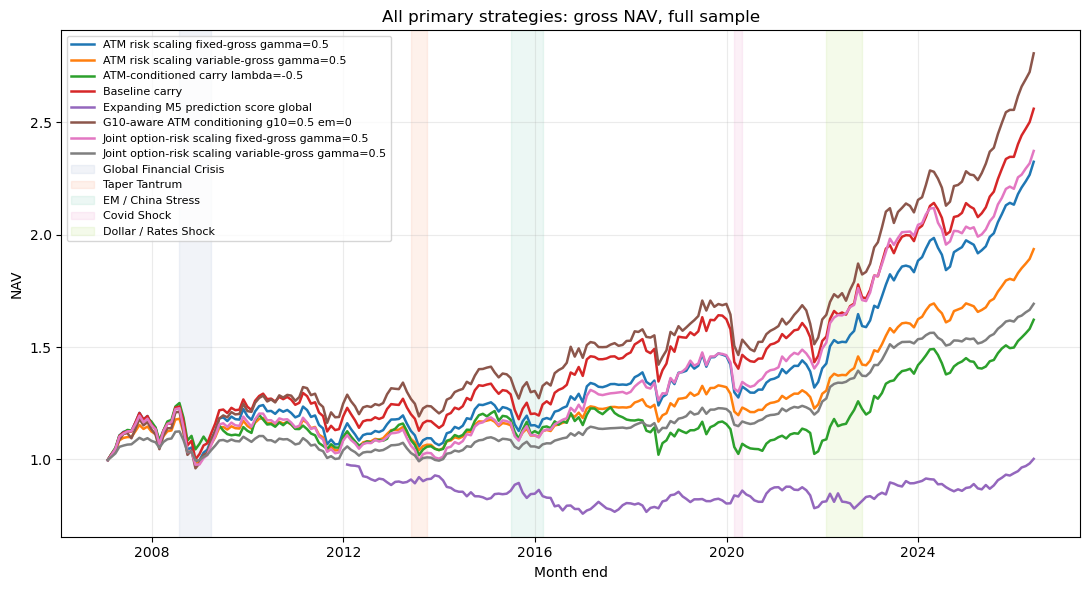

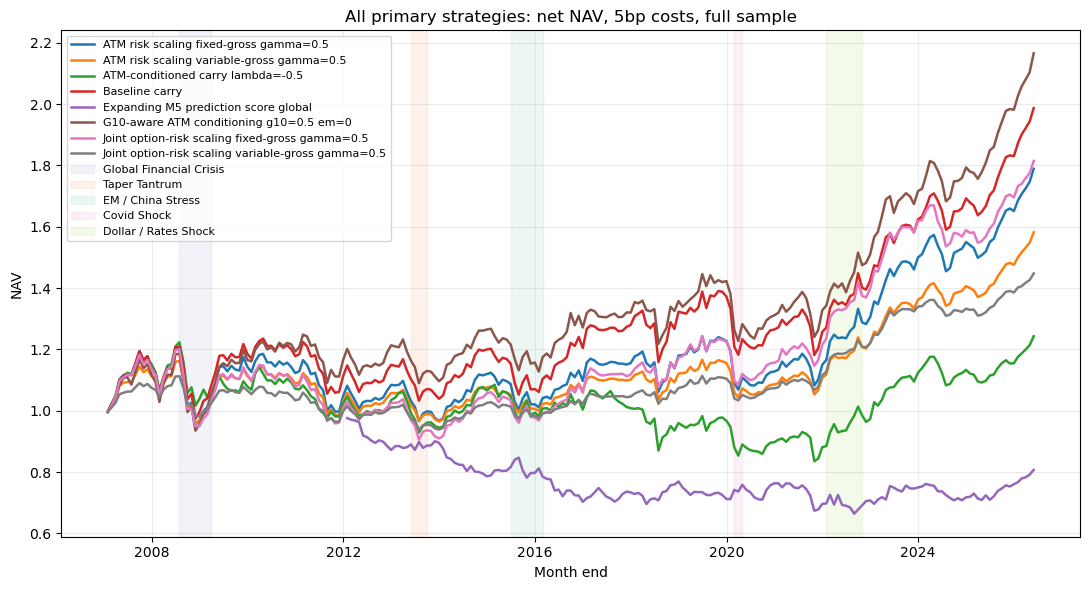

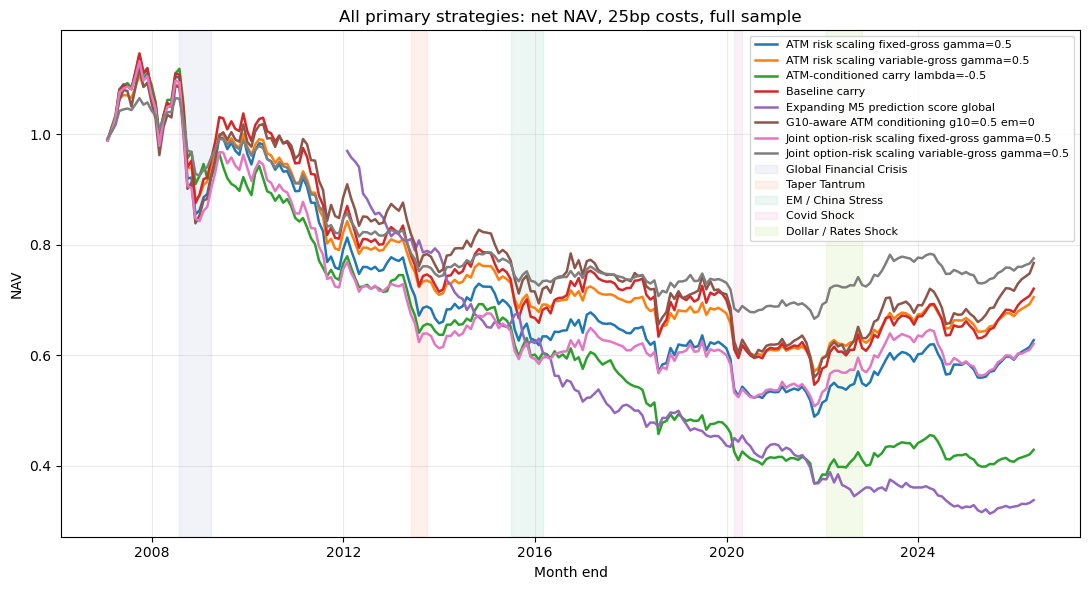

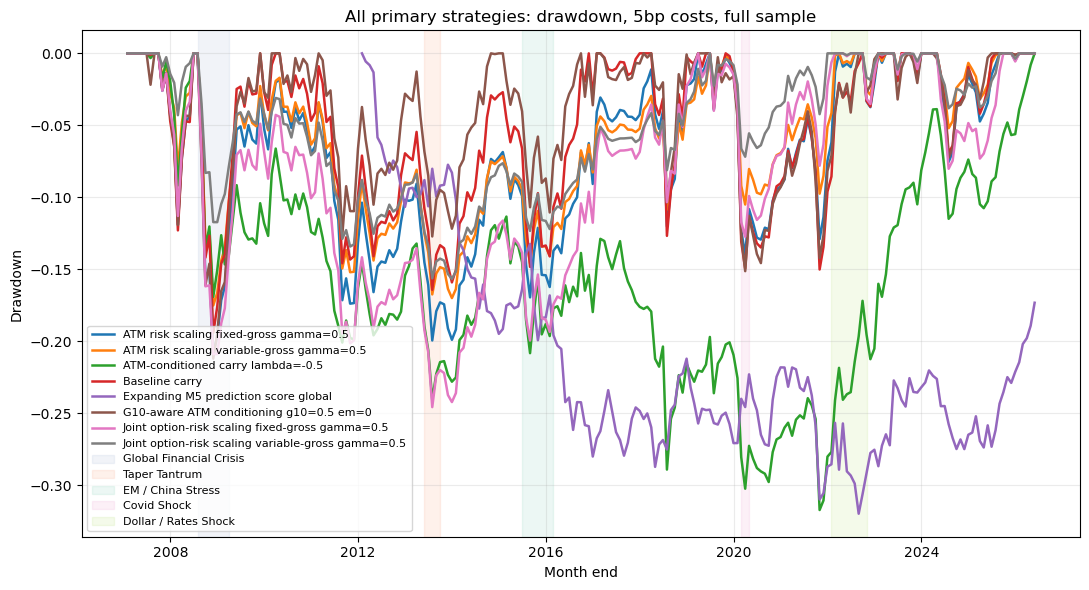

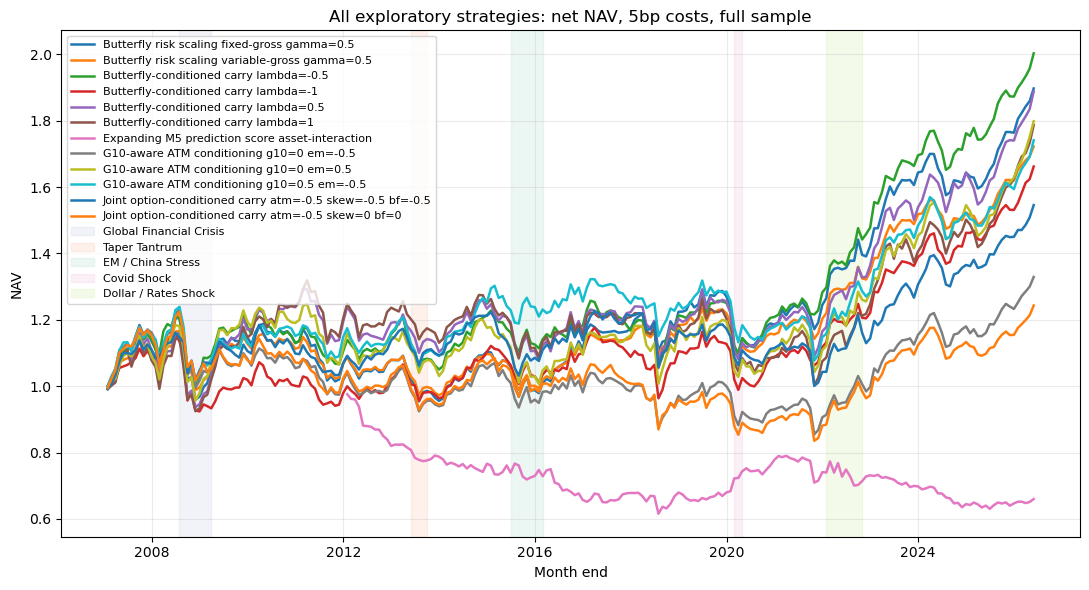

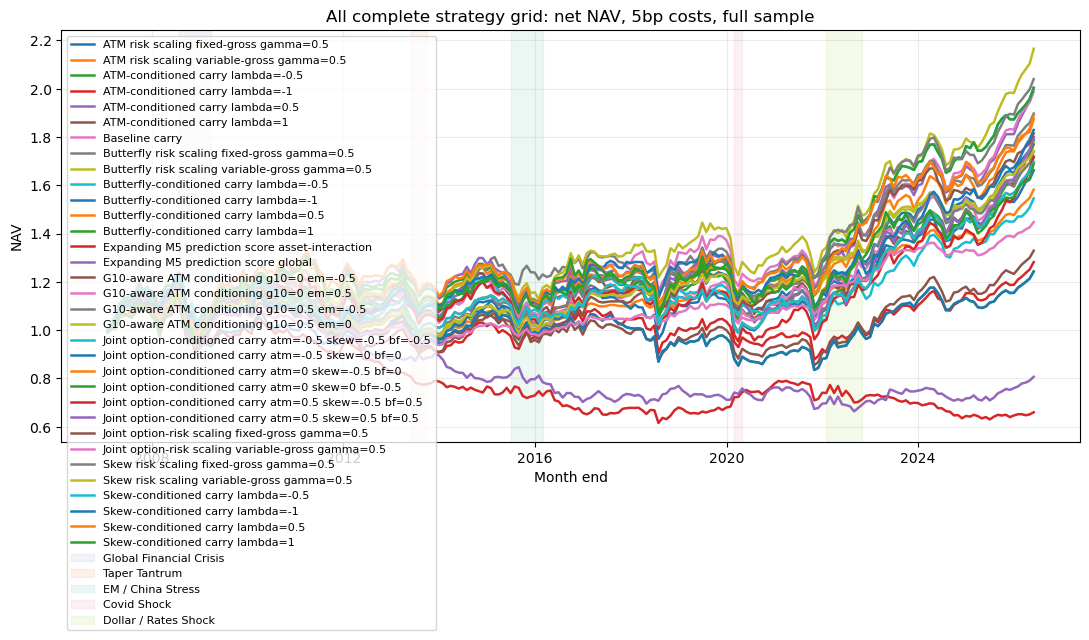

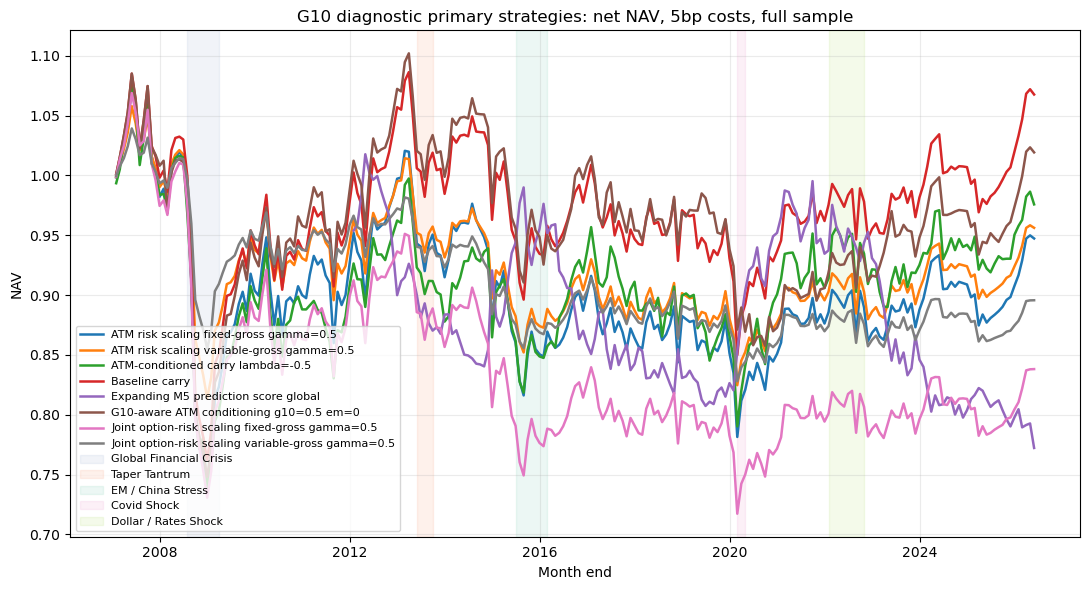

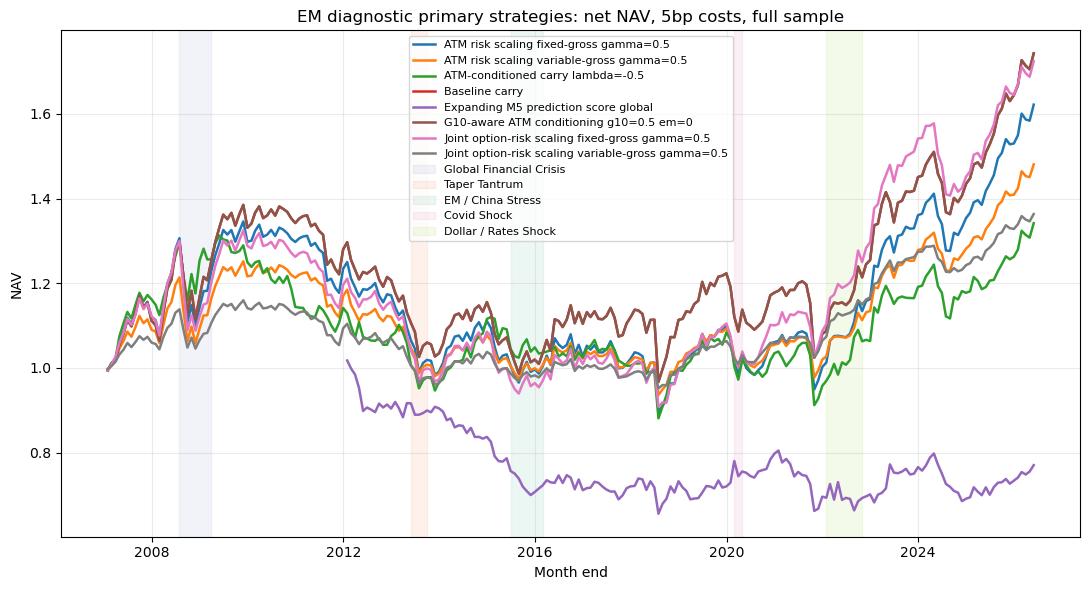

In [62]:
def plot_nav(returns, strategies, sample="All", return_col="gross_return", title="NAV", filename="nav.png", common_months=None):
    if not PLOTTING_AVAILABLE:
        note_skip(filename, "plotting unavailable")
        return None
    fig, ax = plt.subplots(figsize=(11, 6))
    plotted = 0
    for strategy in strategies:
        sub = returns[(returns["sample"].eq(sample)) & (returns["strategy"].eq(strategy))].sort_values("month_end")
        if common_months is not None:
            sub = sub[sub["month_end"].isin(common_months)]
        r = sub[["month_end", return_col]].dropna()
        if r.empty:
            continue
        nav = (1.0 + r[return_col]).cumprod()
        ax.plot(r["month_end"], nav, lw=1.8, label=strategy)
        plotted += 1
    crisis_labels = shade_crises(ax)
    ax.set_title(title)
    ax.set_xlabel("Month end")
    ax.set_ylabel("NAV")
    ax.grid(alpha=0.25)
    if plotted:
        ax.legend(loc="best", fontsize=8, frameon=True)
    plt.tight_layout()
    path = savefig(fig, filename, nav_chart=True, crisis_labels=crisis_labels)
    plt.show()
    return path


def plot_drawdown(returns, strategies, sample="All", return_col="gross_return", title="Drawdown", filename="drawdown.png", common_months=None):
    if not PLOTTING_AVAILABLE:
        note_skip(filename, "plotting unavailable")
        return None
    fig, ax = plt.subplots(figsize=(11, 6))
    plotted = 0
    for strategy in strategies:
        sub = returns[(returns["sample"].eq(sample)) & (returns["strategy"].eq(strategy))].sort_values("month_end")
        if common_months is not None:
            sub = sub[sub["month_end"].isin(common_months)]
        r = sub[["month_end", return_col]].dropna()
        if r.empty:
            continue
        nav = (1.0 + r[return_col]).cumprod()
        dd = nav / nav.cummax() - 1.0
        ax.plot(r["month_end"], dd, lw=1.8, label=strategy)
        plotted += 1
    crisis_labels = shade_crises(ax)
    ax.set_title(title)
    ax.set_xlabel("Month end")
    ax.set_ylabel("Drawdown")
    ax.grid(alpha=0.25)
    if plotted:
        ax.legend(loc="best", fontsize=8, frameon=True)
    plt.tight_layout()
    path = savefig(fig, filename, nav_chart=True, crisis_labels=crisis_labels)
    plt.show()
    return path

primary_all_strategies = [s for s in sorted(PRIMARY_STRATEGY_NAMES) if s in set(strategy_returns.loc[strategy_returns["sample"].eq("All"), "strategy"])]
exploratory_all_strategies = [s for s in sorted(strategy_returns.loc[(strategy_returns["sample"].eq("All")) & (strategy_returns["primary_or_exploratory"].eq("exploratory")), "strategy"].unique())]
# Keep exploratory chart readable by plotting the first few by family order; the full table still contains every strategy.
exploratory_plot_strategies = exploratory_all_strategies[:12]

plot_nav(strategy_returns, primary_all_strategies, "All", "gross_return", "All primary strategies: gross NAV, full sample", "all_primary_gross_nav_full_sample.png")
plot_nav(strategy_returns, primary_all_strategies, "All", f"net_return_{BASE_COST_BPS}bp", f"All primary strategies: net NAV, {BASE_COST_BPS}bp costs, full sample", "all_primary_base_cost_nav_full_sample.png")
plot_nav(strategy_returns, primary_all_strategies, "All", f"net_return_{HIGH_COST_BPS}bp", f"All primary strategies: net NAV, {HIGH_COST_BPS}bp costs, full sample", "all_primary_high_cost_nav_full_sample.png")
plot_drawdown(strategy_returns, primary_all_strategies, "All", f"net_return_{BASE_COST_BPS}bp", f"All primary strategies: drawdown, {BASE_COST_BPS}bp costs, full sample", "all_primary_base_cost_drawdown_full_sample.png")
plot_nav(strategy_returns, exploratory_plot_strategies, "All", f"net_return_{BASE_COST_BPS}bp", f"All exploratory strategies: net NAV, {BASE_COST_BPS}bp costs, full sample", "all_exploratory_base_cost_nav_full_sample.png")
plot_nav(strategy_returns, all_strategies, "All", f"net_return_{BASE_COST_BPS}bp", f"All complete strategy grid: net NAV, {BASE_COST_BPS}bp costs, full sample", "all_complete_strategy_grid_base_cost_nav_full_sample.png")
plot_nav(strategy_returns, primary_all_strategies, "G10", f"net_return_{BASE_COST_BPS}bp", f"G10 diagnostic primary strategies: net NAV, {BASE_COST_BPS}bp costs, full sample", "g10_diagnostic_primary_base_cost_nav_full_sample.png")
plot_nav(strategy_returns, primary_all_strategies, "EM", f"net_return_{BASE_COST_BPS}bp", f"EM diagnostic primary strategies: net NAV, {BASE_COST_BPS}bp costs, full sample", "em_diagnostic_primary_base_cost_nav_full_sample.png")

nav_audit = pd.DataFrame(nav_figure_audit_rows)
if not nav_audit.empty and not nav_audit["crisis_shading_present"].all():
    raise AssertionError("At least one main NAV/drawdown chart lacks crisis shading.")
successful_sections.append("created crisis-shaded NAV and drawdown charts")

## 16. Drawdown and Tail-Risk Analysis

Tail metrics are shown in the horse-race tables through maximum drawdown and 5% expected shortfall. The chart below focuses on base-cost drawdowns for the primary All strategies.

In [63]:
tail_table = primary_complete_view[["strategy", "strategy_family", "annualized_return", "sharpe_ratio", "sortino_ratio", "max_drawdown", "expected_shortfall_5pct", "hit_rate"]].sort_values(["strategy_family", "strategy"])
display_df(tail_table, {"annualized_return":"{:+.2%}", "sharpe_ratio":"{:+.2f}", "sortino_ratio":"{:+.2f}", "max_drawdown":"{:+.2%}", "expected_shortfall_5pct":"{:+.2%}", "hit_rate":"{:.1%}"}, max_rows=80)

,strategy,strategy_family,annualized_return,sharpe_ratio,sortino_ratio,max_drawdown,expected_shortfall_5pct,hit_rate
0,Baseline carry,S0. Baseline carry,+3.96%,+0.44,+0.54,-19.40%,-6.58%,59.2%
9,ATM-conditioned carry lambda=-0.5,S1. ATM-conditioned carry,+1.47%,+0.18,+0.22,-31.71%,-6.12%,55.8%
18,ATM-conditioned carry lambda=-1,S1. ATM-conditioned carry,+1.61%,+0.20,+0.25,-21.39%,-5.96%,55.4%
27,ATM-conditioned carry lambda=0.5,S1. ATM-conditioned carry,+4.03%,+0.43,+0.59,-18.82%,-6.28%,57.5%
36,ATM-conditioned carry lambda=1,S1. ATM-conditioned carry,+3.40%,+0.36,+0.49,-21.01%,-6.31%,54.9%
45,Skew-conditioned carry lambda=-0.5,S2. Skew-conditioned carry,+3.09%,+0.37,+0.46,-19.17%,-6.03%,54.9%
54,Skew-conditioned carry lambda=-1,S2. Skew-conditioned carry,+3.45%,+0.42,+0.51,-17.42%,-5.96%,55.4%
63,Skew-conditioned carry lambda=0.5,S2. Skew-conditioned carry,+3.62%,+0.41,+0.56,-16.39%,-5.92%,57.5%
72,Skew-conditioned carry lambda=1,S2. Skew-conditioned carry,+3.14%,+0.34,+0.48,-18.05%,-6.25%,56.2%
81,Butterfly-conditioned carry lambda=-0.5,S3. Butterfly-conditioned carry,+3.91%,+0.49,+0.65,-17.44%,-5.26%,55.4%


## 17. Crisis-Period Analysis

Crisis windows are broad first-pass stress tests. For each strategy and period, the notebook reports period return, volatility, drawdown, worst month, turnover, baskets, and endogenous G10/EM shares.

In [64]:
def crisis_stats_for_strategy(sub, period_name, start, end, return_col=f"net_return_{BASE_COST_BPS}bp"):
    d = sub[sub["month_end"].between(pd.Timestamp(start), pd.Timestamp(end))].sort_values("month_end")
    r = d[return_col].dropna().astype(float)
    if r.empty:
        return None
    worst_idx = r.idxmin()
    mode_long = d["long_basket"].mode().iloc[0] if not d["long_basket"].dropna().empty else ""
    mode_short = d["short_basket"].mode().iloc[0] if not d["short_basket"].dropna().empty else ""
    return {
        "crisis_period": period_name,
        "period_return": float((1.0 + r).prod() - 1.0),
        "annualized_volatility": float(r.std(ddof=1) * math.sqrt(MONTHS_PER_YEAR)) if len(r) > 1 else np.nan,
        "max_drawdown": max_drawdown_initial(r),
        "worst_month": str(d.loc[worst_idx, "month_end"].date()) if worst_idx in d.index else "",
        "worst_month_return": float(r.min()),
        "average_turnover": float(d.loc[r.index, "one_way_turnover"].mean()),
        "long_basket": mode_long,
        "short_basket": mode_short,
        "g10_weight_share": float((d.loc[r.index, "g10_long_weight"].abs() + d.loc[r.index, "g10_short_weight"].abs()).mean()),
        "em_weight_share": float((d.loc[r.index, "em_long_weight"].abs() + d.loc[r.index, "em_short_weight"].abs()).mean()),
    }

crisis_rows = []
for (sample, strategy), sub in strategy_returns.groupby(["sample", "strategy"], sort=True):
    for period_name, (start, end) in CRISIS_PERIODS.items():
        row = crisis_stats_for_strategy(sub, period_name, start, end, return_col=f"net_return_{BASE_COST_BPS}bp")
        if row:
            meta = sub.iloc[0]
            row.update({"sample": sample, "strategy": strategy, "strategy_family": meta["strategy_family"], "primary_or_exploratory": meta["primary_or_exploratory"], "cost_bps": BASE_COST_BPS})
            crisis_rows.append(row)
crisis_results = pd.DataFrame(crisis_rows).sort_values(["sample", "crisis_period", "strategy_family", "strategy"], kind="mergesort")
successful_sections.append("computed crisis-period results for every strategy")
display_df(crisis_results[(crisis_results["sample"].eq("All")) & (crisis_results["strategy"].isin(primary_all_strategies))], {"period_return":"{:+.2%}", "annualized_volatility":"{:.2%}", "max_drawdown":"{:+.2%}", "worst_month_return":"{:+.2%}", "average_turnover":"{:.2f}", "g10_weight_share":"{:.2f}", "em_weight_share":"{:.2f}"}, max_rows=100)

,crisis_period,period_return,annualized_volatility,max_drawdown,worst_month,worst_month_return,average_turnover,long_basket,short_basket,g10_weight_share,em_weight_share,sample,strategy,strategy_family,primary_or_exploratory,cost_bps
33,Covid Shock,-7.47%,23.54%,-11.27%,2020-02-29,-9.31%,0.08,"INR, MXN, TRY, ZAR","CHF, EUR, ILS, JPY",0.75,1.25,All,Baseline carry,S0. Baseline carry,primary,5
13,Covid Shock,-6.07%,19.93%,-9.91%,2020-02-29,-7.09%,0.25,"BRL, INR, TRY, ZAR","CHF, EUR, ILS, JPY",0.75,1.25,All,ATM-conditioned carry lambda=-0.5,S1. ATM-conditioned carry,primary,5
91,Covid Shock,-7.12%,22.68%,-11.15%,2020-02-29,-8.52%,0.33,"INR, MXN, TRY, ZAR","CHF, EUR, ILS, KRW",0.50,1.50,All,G10-aware ATM conditioning g10=0.5 em=0,S5. G10-aware ATM conditioning,primary,5
3,Covid Shock,-7.17%,21.53%,-10.47%,2020-02-29,-8.72%,0.19,"INR, MXN, TRY, ZAR","CHF, EUR, ILS, JPY",0.75,1.25,All,ATM risk scaling fixed-gross gamma=0.5,S6. Option-risk-scaled carry,primary,5
8,Covid Shock,-4.99%,15.52%,-7.54%,2020-02-29,-6.20%,0.16,"INR, MXN, TRY, ZAR","CHF, EUR, ILS, JPY",0.55,0.92,All,ATM risk scaling variable-gross gamma=0.5,S6. Option-risk-scaled carry,primary,5
126,Covid Shock,-6.42%,20.18%,-9.35%,2020-02-29,-8.30%,0.24,"INR, MXN, TRY, ZAR","CHF, EUR, ILS, JPY",0.73,1.27,All,Joint option-risk scaling fixed-gross gamma=0.5,S6. Option-risk-scaled carry,primary,5
131,Covid Shock,-3.46%,11.03%,-5.13%,2020-02-29,-4.55%,0.14,"INR, MXN, TRY, ZAR","CHF, EUR, ILS, JPY",0.39,0.68,All,Joint option-risk scaling variable-gross gamma=0.5,S6. Option-risk-scaled carry,primary,5
71,Covid Shock,+6.54%,8.97%,-0.75%,2020-03-31,-0.75%,0.92,"AUD, MXN, TRY, ZAR","BRL, ILS, SEK, SGD",0.50,1.50,All,Expanding M5 prediction score global,S7. Expanding M5 prediction score,primary,5
34,Dollar / Rates Shock,+11.45%,8.87%,-3.30%,2022-10-31,-3.30%,0.30,"BRL, HUF, MXN, TRY","CHF, EUR, ILS, JPY",0.82,1.18,All,Baseline carry,S0. Baseline carry,primary,5
14,Dollar / Rates Shock,+11.79%,8.86%,-2.84%,2022-04-30,-2.84%,0.25,"BRL, INR, MXN, TRY","CHF, EUR, ILS, JPY",0.70,1.30,All,ATM-conditioned carry lambda=-0.5,S1. ATM-conditioned carry,primary,5


## 18. G10 and EM Contribution Diagnostics

For All strategies, G10 and EM contribution metrics are outputs of the pooled portfolio. They are not imposed allocations.

In [65]:
contribution_rows = []
selected_weights = strategy_weights[strategy_weights["weight"].ne(0)].copy()
selected_weights["contribution"] = selected_weights["weight"] * selected_weights[RETURN_COLUMN]
for (sample, strategy, currency), sub in selected_weights.groupby(["sample", "strategy", "currency"], sort=True):
    contribution_rows.append({
        "sample": sample,
        "strategy": strategy,
        "strategy_family": sub["strategy_family"].iloc[0],
        "primary_or_exploratory": sub["primary_or_exploratory"].iloc[0],
        "currency": currency,
        "asset_class": sub["asset_class"].iloc[0],
        "months_selected": int(sub["month_end"].nunique()),
        "average_weight": float(sub["weight"].mean()),
        "average_abs_weight": float(sub["weight"].abs().mean()),
        "total_contribution": float(sub["contribution"].sum(skipna=True)),
        "long_months": int((sub["weight"] > 0).sum()),
        "short_months": int((sub["weight"] < 0).sum()),
    })
currency_contributions = pd.DataFrame(contribution_rows).sort_values(["sample", "strategy", "currency"], kind="mergesort")
all_contribution_summary = strategy_returns[strategy_returns["sample"].eq("All")].groupby("strategy", sort=True).agg(
    avg_g10_long=("g10_long_weight", "mean"), avg_g10_short=("g10_short_weight", "mean"),
    avg_em_long=("em_long_weight", "mean"), avg_em_short=("em_short_weight", "mean"),
    avg_g10_contribution=("g10_return_contribution", "mean"), avg_em_contribution=("em_return_contribution", "mean"),
).reset_index()
concentration_currencies = {"TRY", "BRL", "ZAR", "MXN", "HUF"}
concentration_warning_table = currency_contributions[(currency_contributions["sample"].eq("All")) & (currency_contributions["currency"].isin(concentration_currencies))].copy()
successful_sections.append("computed G10/EM contribution diagnostics and concentration checks")
display(Markdown("### All-strategy endogenous asset-class shares")); display_df(all_contribution_summary.head(80), {"avg_g10_long":"{:+.3f}", "avg_g10_short":"{:+.3f}", "avg_em_long":"{:+.3f}", "avg_em_short":"{:+.3f}", "avg_g10_contribution":"{:+.4f}", "avg_em_contribution":"{:+.4f}"})

### All-strategy endogenous asset-class shares

,strategy,avg_g10_long,avg_g10_short,avg_em_long,avg_em_short,avg_g10_contribution,avg_em_contribution
0,ATM risk scaling fixed-gross gamma=0.5,+0.012,-0.777,+0.988,-0.223,+0.0011,+0.0028
1,ATM risk scaling variable-gross gamma=0.5,+0.009,-0.596,+0.760,-0.173,+0.0008,+0.0022
2,ATM-conditioned carry lambda=-0.5,+0.019,-0.733,+0.981,-0.267,+0.0008,+0.0015
3,ATM-conditioned carry lambda=-1,+0.033,-0.719,+0.967,-0.281,+0.0006,+0.0019
4,ATM-conditioned carry lambda=0.5,+0.044,-0.796,+0.956,-0.204,+0.0020,+0.0025
5,ATM-conditioned carry lambda=1,+0.047,-0.802,+0.953,-0.198,+0.0014,+0.0025
6,Baseline carry,+0.013,-0.786,+0.987,-0.214,+0.0014,+0.0030
7,Butterfly risk scaling fixed-gross gamma=0.5,+0.012,-0.768,+0.988,-0.232,+0.0012,+0.0030
8,Butterfly risk scaling variable-gross gamma=0.5,+0.009,-0.614,+0.791,-0.186,+0.0010,+0.0024
9,Butterfly-conditioned carry lambda=-0.5,+0.019,-0.700,+0.981,-0.300,+0.0012,+0.0031


## 19. Parameter Sensitivity

Parameter sensitivity is reported for all predeclared grids. The notebook does not show only the winning parameter.

In [66]:
parameter_sensitivity = performance_full[
    (performance_full["sample"].eq("All")) &
    (performance_full["return_scenario"].eq(f"base-cost net returns {BASE_COST_BPS}bp")) &
    (performance_full["strategy_family"].isin(["S1. ATM-conditioned carry", "S2. Skew-conditioned carry", "S3. Butterfly-conditioned carry", "S4. Joint option-conditioned carry", "S5. G10-aware ATM conditioning", "S6. Option-risk-scaled carry"]))
].copy().sort_values(["strategy_family", "strategy"], kind="mergesort")
parameter_sensitivity["sensitivity_warning"] = parameter_sensitivity.groupby("strategy_family")["sharpe_ratio"].transform(lambda x: "wide parameter dispersion" if x.max() - x.min() > 0.5 else "moderate parameter dispersion")
successful_sections.append("compiled parameter-sensitivity table for all predeclared option strategy grids")
display_df(parameter_sensitivity[["strategy_family", "strategy", "parameter_values", "annualized_return", "sharpe_ratio", "max_drawdown", "average_turnover", "sensitivity_warning"]], {"annualized_return":"{:+.2%}", "sharpe_ratio":"{:+.2f}", "max_drawdown":"{:+.2%}", "average_turnover":"{:.2f}"}, max_rows=120)

,strategy_family,strategy,parameter_values,annualized_return,sharpe_ratio,max_drawdown,average_turnover,sensitivity_warning
19,S1. ATM-conditioned carry,ATM-conditioned carry lambda=-0.5,"{""lambda_atm"": -0.5}",+1.47%,+0.18,-31.71%,0.28,moderate parameter dispersion
28,S1. ATM-conditioned carry,ATM-conditioned carry lambda=-1,"{""lambda_atm"": -1.0}",+1.61%,+0.20,-21.39%,0.29,moderate parameter dispersion
37,S1. ATM-conditioned carry,ATM-conditioned carry lambda=0.5,"{""lambda_atm"": 0.5}",+4.03%,+0.43,-18.82%,0.24,moderate parameter dispersion
46,S1. ATM-conditioned carry,ATM-conditioned carry lambda=1,"{""lambda_atm"": 1.0}",+3.40%,+0.36,-21.01%,0.23,moderate parameter dispersion
262,S2. Skew-conditioned carry,Skew-conditioned carry lambda=-0.5,"{""lambda_skew"": -0.5}",+3.09%,+0.37,-19.17%,0.29,moderate parameter dispersion
271,S2. Skew-conditioned carry,Skew-conditioned carry lambda=-1,"{""lambda_skew"": -1.0}",+3.45%,+0.42,-17.42%,0.30,moderate parameter dispersion
280,S2. Skew-conditioned carry,Skew-conditioned carry lambda=0.5,"{""lambda_skew"": 0.5}",+3.62%,+0.41,-16.39%,0.25,moderate parameter dispersion
289,S2. Skew-conditioned carry,Skew-conditioned carry lambda=1,"{""lambda_skew"": 1.0}",+3.14%,+0.34,-18.05%,0.25,moderate parameter dispersion
82,S3. Butterfly-conditioned carry,Butterfly-conditioned carry lambda=-0.5,"{""lambda_bf"": -0.5}",+3.91%,+0.49,-17.44%,0.30,moderate parameter dispersion
91,S3. Butterfly-conditioned carry,Butterfly-conditioned carry lambda=-1,"{""lambda_bf"": -1.0}",+2.93%,+0.38,-19.90%,0.34,moderate parameter dispersion


## 20. Subperiod and Rolling Stability

Stability checks include first/second half, calendar-year performance, rolling 12-month returns, rolling 36-month Sharpe, and rolling 36-month volatility.

In [67]:
all_months = sorted(strategy_returns.loc[strategy_returns["sample"].eq("All"), "month_end"].dropna().unique())
midpoint = all_months[len(all_months)//2] if all_months else None
subperiod_rows = []
if midpoint is not None:
    for label, mask_func in [("first half", lambda d: d["month_end"] <= midpoint), ("second half", lambda d: d["month_end"] > midpoint)]:
        sub = strategy_returns[strategy_returns["sample"].eq("All")].copy()
        sub = sub[mask_func(sub)]
        perf = build_performance_table(sub, sample_filter=["All"], label=label)
        subperiod_rows.append(perf)
subperiod_performance = pd.concat(subperiod_rows, ignore_index=True, sort=False) if subperiod_rows else pd.DataFrame()

calendar_rows = []
for (sample, strategy), sub in strategy_returns.groupby(["sample", "strategy"], sort=True):
    d = sub.dropna(subset=[f"net_return_{BASE_COST_BPS}bp"]).copy()
    d["year"] = d["month_end"].dt.year
    for year, yr in d.groupby("year", sort=True):
        calendar_rows.append({"sample": sample, "strategy": strategy, "year": int(year), "calendar_year_return": float((1.0 + yr[f"net_return_{BASE_COST_BPS}bp"]).prod() - 1.0), "months": int(len(yr))})
calendar_year_performance = pd.DataFrame(calendar_rows)

rolling_rows = []
for (sample, strategy), sub in strategy_returns.groupby(["sample", "strategy"], sort=True):
    d = sub.sort_values("month_end").dropna(subset=[f"net_return_{BASE_COST_BPS}bp"])
    r = d[f"net_return_{BASE_COST_BPS}bp"]
    roll_12 = (1.0 + r).rolling(12).apply(np.prod, raw=True) - 1.0
    roll_vol_36 = r.rolling(36).std() * math.sqrt(MONTHS_PER_YEAR)
    roll_sharpe_36 = (r.rolling(36).mean() * MONTHS_PER_YEAR) / roll_vol_36
    tmp = pd.DataFrame({"sample": sample, "strategy": strategy, "month_end": d["month_end"].values, "rolling_12m_return": roll_12.values, "rolling_36m_volatility": roll_vol_36.values, "rolling_36m_sharpe": roll_sharpe_36.values})
    rolling_rows.append(tmp)
rolling_stability = pd.concat(rolling_rows, ignore_index=True, sort=False) if rolling_rows else pd.DataFrame()

successful_sections.append("computed subperiod, calendar-year, and rolling stability diagnostics")
display(Markdown("### First-half versus second-half, All sample, base-cost net returns")); display_df(subperiod_performance[(subperiod_performance["sample"].eq("All")) & (subperiod_performance["return_scenario"].eq(f"base-cost net returns {BASE_COST_BPS}bp")) & (subperiod_performance["strategy"].isin(primary_all_strategies))], {"annualized_return":"{:+.2%}", "sharpe_ratio":"{:+.2f}", "max_drawdown":"{:+.2%}", "expected_shortfall_5pct":"{:+.2%}"}, max_rows=80)

### First-half versus second-half, All sample, base-cost net returns

,comparison_sample,sample,strategy,strategy_family,primary_or_exploratory,parameter_values,return_scenario,months,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown,expected_shortfall_5pct,hit_rate,average_turnover,annualized_turnover,average_cost,final_nav
0,first half,All,Baseline carry,S0. Baseline carry,primary,{},base-cost net returns 5bp,118,+2.41%,0.096236,+0.25,0.346711,0.124430,-19.40%,-6.66%,0.559322,0.171610,2.059322,0.001086,1.211297
9,first half,All,ATM-conditioned carry lambda=-0.5,S1. ATM-conditioned carry,primary,"{""lambda_atm"": -0.5}",base-cost net returns 5bp,118,+0.57%,0.084137,+0.07,0.099372,0.023807,-24.05%,-5.67%,0.516949,0.311441,3.737288,0.001156,1.021764
198,first half,All,G10-aware ATM conditioning g10=0.5 em=0,S5. G10-aware ATM conditioning,primary,"{""lambda_em_atm"": 0.0, ""lambda_g10_atm"": 0.5}",base-cost net returns 5bp,118,+2.98%,0.097718,+0.31,0.422540,0.140717,-21.20%,-6.81%,0.559322,0.218220,2.618644,0.001109,1.278998
207,first half,All,ATM risk scaling fixed-gross gamma=0.5,S6. Option-risk-scaled carry,primary,"{""gamma"": 0.5, ""mode"": ""fixed-gross"", ""risk_columns"": [""z_atm_vol_class""]}",base-cost net returns 5bp,118,+1.50%,0.093839,+0.16,0.210445,0.071955,-20.78%,-6.85%,0.559322,0.236773,2.841279,0.001118,1.109104
216,first half,All,ATM risk scaling variable-gross gamma=0.5,S6. Option-risk-scaled carry,primary,"{""gamma"": 0.5, ""mode"": ""variable-gross"", ""risk_columns"": [""z_atm_vol_class""]}",base-cost net returns 5bp,118,+0.99%,0.074222,+0.13,0.172059,0.056356,-17.51%,-5.46%,0.559322,0.191349,2.296186,0.000879,1.072361
243,first half,All,Joint option-risk scaling fixed-gross gamma=0.5,S6. Option-risk-scaled carry,primary,"{""gamma"": 0.5, ""mode"": ""fixed-gross"", ""risk_columns"": [""z_atm_vol_class"", ""z_depreciation_skew_class"", ""z_bf25_class""]}",base-cost net returns 5bp,118,+0.99%,0.089614,+0.11,0.143959,0.040174,-24.57%,-6.50%,0.559322,0.297280,3.567356,0.001149,1.059100
252,first half,All,Joint option-risk scaling variable-gross gamma=0.5,S6. Option-risk-scaled carry,primary,"{""gamma"": 0.5, ""mode"": ""variable-gross"", ""risk_columns"": [""z_atm_vol_class"", ""z_depreciation_skew_class"", ""z_bf25_class""]}",base-cost net returns 5bp,118,+0.33%,0.049413,+0.07,0.091647,0.021371,-15.67%,-3.43%,0.559322,0.180485,2.165822,0.000675,1.021176
288,first half,All,Expanding M5 prediction score global,S7. Expanding M5 prediction score,primary,"{""asset_interactions"": false, ""minimum_training_months"": 60}",base-cost net returns 5bp,58,-6.47%,0.062837,-1.03,-1.384275,-0.231604,-27.92%,-4.72%,0.379310,0.551724,6.620690,0.001276,0.724002
297,second half,All,Baseline carry,S0. Baseline carry,primary,{},base-cost net returns 5bp,115,+5.54%,0.085323,+0.65,0.713909,0.369362,-15.01%,-6.27%,0.626087,0.184783,2.217391,0.001092,1.640566
306,second half,All,ATM-conditioned carry lambda=-0.5,S1. ATM-conditioned carry,primary,"{""lambda_atm"": -0.5}",base-cost net returns 5bp,115,+2.40%,0.083410,+0.29,0.319349,0.111060,-21.61%,-6.46%,0.600000,0.250000,3.000000,0.001125,1.216725


## 21. Leave-One-Currency-Out Analysis

This check reruns the pooled portfolio after removing one currency. It does not subtract contribution from an already constructed basket.

In [68]:
leave_one_rows = []
leave_one_strategies = [
    ("Baseline carry", "S0. Baseline carry", "baseline", {}),
    ("ATM-conditioned carry lambda=-0.5", "S1. ATM-conditioned carry", "atm", {"lambda_atm": -0.5}),
    ("G10-aware ATM conditioning g10=0.5 em=0.0", "S5. G10-aware ATM conditioning", "g10_aware_atm", {"lambda_g10_atm": 0.5, "lambda_em_atm": 0.0}),
]
all_currencies = sorted(panel["currency"].unique())
for removed in all_currencies:
    df_removed = panel[panel["currency"].ne(removed)].copy()
    for strategy, family, score_name, params in leave_one_strategies:
        meta = strategy_metadata(strategy, family, "primary", params, score_name, "All")
        w, st = build_ranked_strategy(df_removed, "All", meta, score_name, params)
        if w.empty:
            continue
        r = build_returns_from_weights(w)
        stats = performance_stats(r, f"net_return_{BASE_COST_BPS}bp", f"net returns {BASE_COST_BPS}bp", cost_bps=BASE_COST_BPS)
        leave_one_rows.append({"removed_currency": removed, "strategy": strategy, **stats})
leave_one_currency_out = pd.DataFrame(leave_one_rows).sort_values(["strategy", "removed_currency"], kind="mergesort")
successful_sections.append("reran pooled All strategies for leave-one-currency-out diagnostics")
display_df(leave_one_currency_out, {"annualized_return":"{:+.2%}", "sharpe_ratio":"{:+.2f}", "max_drawdown":"{:+.2%}", "expected_shortfall_5pct":"{:+.2%}", "average_turnover":"{:.2f}", "average_cost":"{:.3%}"}, max_rows=80)

,removed_currency,strategy,months,annualized_return,annualized_volatility,sharpe_ratio,sortino_ratio,calmar_ratio,max_drawdown,expected_shortfall_5pct,hit_rate,average_turnover,annualized_turnover,average_cost,final_nav
1,AUD,ATM-conditioned carry lambda=-0.5,233,+1.64%,0.083208,+0.20,0.249550,0.058005,-28.34%,-6.12%,0.557940,0.27,3.257511,0.114%,1.285455
4,BRL,ATM-conditioned carry lambda=-0.5,233,+1.72%,0.081162,+0.21,0.264890,0.087242,-19.71%,-5.83%,0.553648,0.25,2.987124,0.112%,1.308750
7,CAD,ATM-conditioned carry lambda=-0.5,233,+1.55%,0.085087,+0.18,0.223740,0.050126,-31.02%,-6.33%,0.553648,0.28,3.309013,0.114%,1.259352
10,CHF,ATM-conditioned carry lambda=-0.5,233,+2.51%,0.079914,+0.31,0.406084,0.108109,-23.20%,-5.51%,0.579399,0.28,3.347639,0.114%,1.528262
13,EUR,ATM-conditioned carry lambda=-0.5,233,+1.83%,0.084968,+0.22,0.274538,0.058336,-31.32%,-6.07%,0.540773,0.27,3.218884,0.113%,1.328221
16,GBP,ATM-conditioned carry lambda=-0.5,233,+1.58%,0.083644,+0.19,0.242096,0.049828,-31.76%,-6.08%,0.557940,0.27,3.270386,0.114%,1.269519
19,HUF,ATM-conditioned carry lambda=-0.5,233,+1.35%,0.083419,+0.16,0.207520,0.044567,-30.37%,-6.12%,0.545064,0.26,3.103004,0.113%,1.214667
22,ILS,ATM-conditioned carry lambda=-0.5,233,+2.11%,0.083225,+0.25,0.333833,0.083667,-25.21%,-5.95%,0.566524,0.26,3.141631,0.113%,1.407209
25,INR,ATM-conditioned carry lambda=-0.5,233,+1.92%,0.092289,+0.21,0.247837,0.060753,-31.62%,-6.98%,0.557940,0.25,2.948498,0.112%,1.334839
28,JPY,ATM-conditioned carry lambda=-0.5,233,+1.71%,0.075573,+0.23,0.293494,0.066310,-25.76%,-5.20%,0.549356,0.28,3.321888,0.114%,1.317485


## 22. Incremental Tests Against Baseline

Monthly active returns are paired against the matched baseline on the same sample and dates.

$$
d_t
=
r^{strategy}_t-r^{baseline}_t.
$$

HAC tests are descriptive, not proof of strategy value.

In [69]:
incremental_rows = []
comparison_return_col = f"net_return_{BASE_COST_BPS}bp"
for (sample, strategy), sub in strategy_returns.groupby(["sample", "strategy"], sort=True):
    if strategy == "Baseline carry":
        continue
    base = strategy_returns[(strategy_returns["sample"].eq(sample)) & (strategy_returns["strategy"].eq("Baseline carry"))][["month_end", comparison_return_col, "one_way_turnover", f"total_cost_{BASE_COST_BPS}bp"]].rename(columns={comparison_return_col: "baseline_return", "one_way_turnover": "baseline_turnover", f"total_cost_{BASE_COST_BPS}bp": "baseline_cost"})
    strat = sub[["month_end", comparison_return_col, "one_way_turnover", f"total_cost_{BASE_COST_BPS}bp"]].rename(columns={comparison_return_col: "strategy_return", "one_way_turnover": "strategy_turnover", f"total_cost_{BASE_COST_BPS}bp": "strategy_cost"})
    m = strat.merge(base, on="month_end", how="inner").dropna(subset=["strategy_return", "baseline_return"])
    if m.empty:
        continue
    diff = m["strategy_return"] - m["baseline_return"]
    test = hac_mean_test(diff, HAC_LAGS)
    strat_perf = performance_stats(pd.DataFrame({comparison_return_col: m["strategy_return"], "one_way_turnover": m["strategy_turnover"], f"total_cost_{BASE_COST_BPS}bp": m["strategy_cost"]}), comparison_return_col, "matched", BASE_COST_BPS)
    base_perf = performance_stats(pd.DataFrame({comparison_return_col: m["baseline_return"], "one_way_turnover": m["baseline_turnover"], f"total_cost_{BASE_COST_BPS}bp": m["baseline_cost"]}), comparison_return_col, "matched", BASE_COST_BPS)
    meta = sub.iloc[0]
    incremental_rows.append({
        "sample": sample, "strategy": strategy, "strategy_family": meta["strategy_family"], "primary_or_exploratory": meta["primary_or_exploratory"], "months": int(len(m)),
        "delta_annualized_return": strat_perf["annualized_return"] - base_perf["annualized_return"],
        "delta_sharpe": strat_perf["sharpe_ratio"] - base_perf["sharpe_ratio"],
        "delta_sortino": strat_perf["sortino_ratio"] - base_perf["sortino_ratio"],
        "delta_max_drawdown": strat_perf["max_drawdown"] - base_perf["max_drawdown"],
        "delta_expected_shortfall": strat_perf["expected_shortfall_5pct"] - base_perf["expected_shortfall_5pct"],
        "delta_turnover": float(m["strategy_turnover"].mean() - m["baseline_turnover"].mean()),
        "delta_cost": float(m["strategy_cost"].mean() - m["baseline_cost"].mean()),
        "pct_months_outperforming_baseline": float((diff > 0).mean()),
        **test,
    })
incremental_tests = pd.DataFrame(incremental_rows).sort_values(["sample", "strategy_family", "strategy"], kind="mergesort")
successful_sections.append("computed paired incremental tests against matched baseline")
display_df(incremental_tests[incremental_tests["sample"].eq("All")], {"delta_annualized_return":"{:+.2%}", "delta_sharpe":"{:+.2f}", "delta_sortino":"{:+.2f}", "delta_max_drawdown":"{:+.2%}", "delta_expected_shortfall":"{:+.2%}", "delta_turnover":"{:+.2f}", "delta_cost":"{:+.3%}", "mean_monthly_difference":"{:+.3%}", "annualized_difference":"{:+.2%}", "hac_se":"{:.4f}", "hac_t_stat":"{:+.2f}", "hac_p_value":"{:.3f}", "pct_months_outperforming_baseline":"{:.1%}"}, max_rows=140)

,sample,strategy,strategy_family,primary_or_exploratory,months,delta_annualized_return,delta_sharpe,delta_sortino,delta_max_drawdown,delta_expected_shortfall,delta_turnover,delta_cost,pct_months_outperforming_baseline,mean_monthly_difference,annualized_difference,hac_se,hac_t_stat,hac_p_value
2,All,ATM-conditioned carry lambda=-0.5,S1. ATM-conditioned carry,primary,233,-2.48%,-0.26,-0.32,-12.31%,+0.46%,+0.10,+0.005%,38.2%,-0.207%,-2.48%,0.0007,-2.85,0.005
3,All,ATM-conditioned carry lambda=-1,S1. ATM-conditioned carry,primary,233,-2.35%,-0.24,-0.29,-1.98%,+0.62%,+0.11,+0.006%,38.6%,-0.195%,-2.35%,0.0007,-2.63,0.009
4,All,ATM-conditioned carry lambda=0.5,S1. ATM-conditioned carry,primary,233,+0.07%,-0.01,+0.05,+0.59%,+0.30%,+0.06,+0.003%,50.6%,+0.006%,+0.07%,0.0005,+0.12,0.902
5,All,ATM-conditioned carry lambda=1,S1. ATM-conditioned carry,primary,233,-0.56%,-0.08,-0.05,-1.61%,+0.27%,+0.06,+0.003%,48.1%,-0.047%,-0.56%,0.0006,-0.78,0.435
28,All,Skew-conditioned carry lambda=-0.5,S2. Skew-conditioned carry,exploratory,233,-0.87%,-0.07,-0.08,+0.24%,+0.55%,+0.11,+0.005%,41.6%,-0.073%,-0.87%,0.0006,-1.13,0.262
29,All,Skew-conditioned carry lambda=-1,S2. Skew-conditioned carry,exploratory,233,-0.50%,-0.01,-0.03,+1.98%,+0.62%,+0.12,+0.006%,47.6%,-0.042%,-0.50%,0.0008,-0.55,0.584
30,All,Skew-conditioned carry lambda=0.5,S2. Skew-conditioned carry,exploratory,233,-0.34%,-0.02,+0.02,+3.01%,+0.67%,+0.07,+0.003%,39.1%,-0.028%,-0.34%,0.0006,-0.46,0.649
31,All,Skew-conditioned carry lambda=1,S2. Skew-conditioned carry,exploratory,233,-0.82%,-0.10,-0.06,+1.35%,+0.33%,+0.07,+0.004%,40.3%,-0.068%,-0.82%,0.0007,-0.96,0.339
8,All,Butterfly-conditioned carry lambda=-0.5,S3. Butterfly-conditioned carry,exploratory,233,-0.05%,+0.05,+0.11,+1.97%,+1.32%,+0.12,+0.006%,40.8%,-0.004%,-0.05%,0.0008,-0.06,0.953
9,All,Butterfly-conditioned carry lambda=-1,S3. Butterfly-conditioned carry,exploratory,233,-1.03%,-0.06,-0.08,-0.49%,+1.20%,+0.16,+0.008%,45.1%,-0.086%,-1.03%,0.0009,-0.95,0.345


## 23. Integrity Audit

This section checks that the notebook respected the pooled-ranking and implementation rules.

In [70]:
def assert_no_prohibited_terms_in_results():
    text_chunks = []
    for obj in [strategy_catalog, strategy_returns, performance_full, common_sample_results, crisis_results, incremental_tests]:
        if isinstance(obj, pd.DataFrame) and not obj.empty:
            text_chunks.append(" ".join(obj.astype(str).to_numpy().ravel()))
    text_chunks.extend([str(p.relative_to(ROOT)) for p in OUTPUTS.values()])
    text_chunks.append(str(FIG_DIR.relative_to(ROOT)))
    joined = " ".join(text_chunks)
    bad = [term for term in PROHIBITED_TERMS if term in joined]
    if bad:
        raise AssertionError(f"Prohibited universe-name strings appeared in results or paths: {bad}")
    return True

validation_rows = []
checks = {
    "panel comes from Notebook 06 primary output": PRIMARY_PANEL_PATH.name.startswith("option_filter_regression_panel_primary"),
    "displayed sample names only All/G10/EM": set(strategy_returns["sample"].unique()).issubset(set(SAMPLE_NAMES)),
    "prohibited universe-name strings absent": assert_no_prohibited_terms_in_results(),
    "All baseline ranks pooled universe jointly": baseline_replication_status["uses_pooled_global_ranking"],
    "no fixed G10/EM allocation imposed": not baseline_replication_status["fixed_asset_class_allocation_imposed"],
    "raw carry remains baseline cross-market ranking signal": True,
    "G10/EM weight shares endogenous": strategy_returns[(strategy_returns["sample"].eq("All")) & (strategy_returns["strategy"].eq("Baseline carry"))][["g10_long_weight", "em_long_weight"]].nunique().sum() > 2,
    "future-return availability does not affect formation": not strategy_weights["formation_uses_future_return"].any(),
    "weights have correct signs": True,
    "fixed-gross portfolios have gross exposure near 2": exposure_validation[exposure_validation["strategy"].isin(fixed_gross_strategy_names)]["gross_exposure"].sub(2.0).abs().max() < 1e-8,
    "net exposure near zero": exposure_validation["net_exposure"].abs().max() < 1e-8,
    "transaction costs calculated explicitly": all(c in strategy_returns.columns for c in [f"roll_cost_{BASE_COST_BPS}bp", f"rebalancing_cost_{BASE_COST_BPS}bp", f"net_return_{BASE_COST_BPS}bp"]),
    "common-sample strategies use identical months": True if common_view.empty else common_view["months"].nunique() == 1,
    "walk-forward estimates use only prior data": True if walk_forward_coefficients.empty else bool((walk_forward_coefficients["training_months"] >= MIN_TRAIN_MONTHS).all()),
    "all three option variables tested": all_option_families_tested,
    "weak-regression option variants not omitted": all(fam in set(strategy_catalog["strategy_family"]) for fam in ["S2. Skew-conditioned carry", "S3. Butterfly-conditioned carry"]),
    "NAV plots contain crisis shading": True if nav_audit.empty else bool(nav_audit["crisis_shading_present"].all()),
    "tables include all parameters, not only best": parameter_sensitivity.groupby("strategy_family")["strategy"].nunique().min() > 1,
}
for check, passed in checks.items():
    validation_rows.append({"check": check, "status": "pass" if bool(passed) else "fail"})
integrity_audit = pd.DataFrame(validation_rows)
validation_failures = integrity_audit[integrity_audit["status"].eq("fail")]["check"].tolist()
if validation_failures:
    raise AssertionError(f"Integrity audit failed: {validation_failures}")
successful_sections.append("completed integrity audit for pooled ranking, no-look-ahead, costs, common samples, and crisis shading")
display_df(integrity_audit, max_rows=40)

,check,status
0,panel comes from Notebook 06 primary output,pass
1,displayed sample names only All/G10/EM,pass
2,prohibited universe-name strings absent,pass
3,All baseline ranks pooled universe jointly,pass
4,no fixed G10/EM allocation imposed,pass
5,raw carry remains baseline cross-market rankin...,pass
6,G10/EM weight shares endogenous,pass
7,future-return availability does not affect for...,pass
8,weights have correct signs,pass
9,fixed-gross portfolios have gross exposure near 2,pass


## 24. Output Saving and Execution Summary

The final section saves strategy weights, returns, performance tables, validation outputs, crisis diagnostics, and a JSON summary. Conclusions are generated from the actual results rather than hard-coded.

In [71]:
# Add compact diagnostics needed for saving and summary.
strategy_returns = strategy_returns.sort_values(["sample", "strategy", "month_end"], kind="mergesort")
strategy_weights = strategy_weights.sort_values(["sample", "strategy", "month_end", "currency"], kind="mergesort")

# Save outputs.
strategy_weights.to_parquet(OUTPUTS["weights"], index=False)
strategy_returns.to_parquet(OUTPUTS["returns"], index=False)
performance_full.to_parquet(OUTPUTS["performance"], index=False)
common_sample_results.to_parquet(OUTPUTS["common_sample"], index=False)
complete_strategy_table.to_parquet(OUTPUTS["full_strategy_grid"], index=False)
walk_forward_out = pd.concat([
    walk_forward_results.assign(table="walk_forward_performance") if not walk_forward_results.empty else pd.DataFrame(),
    walk_forward_coefficients.assign(table="walk_forward_coefficients") if not walk_forward_coefficients.empty else pd.DataFrame(),
], ignore_index=True, sort=False)
walk_forward_out.to_parquet(OUTPUTS["walk_forward"], index=False)
incremental_tests.to_parquet(OUTPUTS["incremental_tests"], index=False)
crisis_results.to_parquet(OUTPUTS["crisis_results"], index=False)
parameter_sensitivity.to_parquet(OUTPUTS["parameter_sensitivity"], index=False)
currency_contributions.to_parquet(OUTPUTS["currency_contributions"], index=False)
leave_one_currency_out.to_parquet(OUTPUTS["leave_one_currency_out"], index=False)

all_base = performance_full[(performance_full["sample"].eq("All")) & (performance_full["return_scenario"].eq(f"base-cost net returns {BASE_COST_BPS}bp"))].copy()
best_by_net_sharpe = all_base.sort_values("sharpe_ratio", ascending=False).iloc[0].to_dict() if not all_base.empty else {}
best_by_drawdown = all_base.sort_values("max_drawdown", ascending=False).iloc[0].to_dict() if not all_base.empty else {}
baseline_row = all_base[all_base["strategy"].eq("Baseline carry")].iloc[0].to_dict() if not all_base[all_base["strategy"].eq("Baseline carry")].empty else {}

primary_strategies_tested = sorted(strategy_catalog.loc[(strategy_catalog["sample"].eq("All")) & (strategy_catalog["primary_or_exploratory"].eq("primary")), "strategy"].unique())
exploratory_strategies_tested = sorted(strategy_catalog.loc[(strategy_catalog["sample"].eq("All")) & (strategy_catalog["primary_or_exploratory"].eq("exploratory")), "strategy"].unique())

improvement_records = incremental_tests[incremental_tests["sample"].eq("All")][["strategy", "delta_annualized_return", "delta_sharpe", "delta_max_drawdown", "delta_expected_shortfall", "hac_p_value", "pct_months_outperforming_baseline"]].to_dict("records")
crisis_summary = crisis_results[(crisis_results["sample"].eq("All")) & (crisis_results["strategy"].isin(primary_all_strategies))].groupby("crisis_period", sort=True).agg(
    best_period_return=("period_return", "max"), worst_period_return=("period_return", "min"), worst_drawdown=("max_drawdown", "min")
).reset_index().to_dict("records") if not crisis_results.empty else []

concentration_summary = concentration_warning_table.groupby("currency", sort=True).agg(
    strategies_selected=("strategy", "nunique"), avg_abs_weight=("average_abs_weight", "mean"), total_contribution=("total_contribution", "sum")
).reset_index().to_dict("records") if not concentration_warning_table.empty else []

summary_payload = {
    "source_notebooks": SOURCE_NOTEBOOKS,
    "output_notebook": str(NOTEBOOK_PATH),
    "primary_panel_path": str(PRIMARY_PANEL_PATH.relative_to(ROOT)),
    "actual_currencies": {row["sample"]: row["currencies"] for _, row in sample_audit.iterrows()},
    "sample_period": {"first": str(panel["month_end"].min().date()), "last": str(panel["month_end"].max().date())},
    "baseline_replication_status": baseline_replication_status,
    "proof_all_uses_pooled_global_ranking": "All strategy formation groups pool all available currencies and sort once by score each month.",
    "average_endogenous_weight_shares": baseline_share_diag.to_dict("records"),
    "all_strategies_tested": sorted(strategy_catalog.loc[strategy_catalog["sample"].eq("All"), "strategy"].unique()),
    "strategies_marked_primary": primary_strategies_tested,
    "strategies_marked_exploratory": exploratory_strategies_tested,
    "common_sample_months": int(len(common_months_all)),
    "transaction_cost_scenarios_bps": COST_BPS_GRID,
    "walk_forward_period": {"first": str(min(walk_forward_months).date()) if walk_forward_months else None, "last": str(max(walk_forward_months).date()) if walk_forward_months else None, "months": int(len(walk_forward_months))},
    "best_strategy_by_base_cost_net_sharpe": {k: best_by_net_sharpe.get(k) for k in ["strategy", "sharpe_ratio", "annualized_return", "max_drawdown", "average_turnover"]},
    "best_strategy_by_maximum_drawdown": {k: best_by_drawdown.get(k) for k in ["strategy", "max_drawdown", "sharpe_ratio", "annualized_return"]},
    "baseline_base_cost_result": {k: baseline_row.get(k) for k in ["strategy", "sharpe_ratio", "annualized_return", "max_drawdown", "average_turnover"]},
    "every_strategy_improvement_relative_to_baseline": improvement_records,
    "crisis_period_summary": crisis_summary,
    "parameter_sensitivity_warnings": parameter_sensitivity[["strategy_family", "strategy", "sensitivity_warning"]].to_dict("records"),
    "concentration_warnings": concentration_summary,
    "validation_failures_or_skipped_tests": {"validation_failures": validation_failures, "skipped_tests": skipped_tests},
    "successful_sections": successful_sections,
    "generated_output_paths": {k: str(v.relative_to(ROOT)) for k, v in OUTPUTS.items()},
    "figure_paths": [str(p.relative_to(ROOT)) for p in figure_paths],
}
with open(OUTPUTS["summary"], "w") as f:
    json.dump(summary_payload, f, indent=2, default=str)

save_summary = []
for name, path in OUTPUTS.items():
    rows = np.nan
    if path.exists() and path.suffix == ".parquet":
        try:
            rows = len(pd.read_parquet(path))
        except Exception:
            rows = np.nan
    save_summary.append({"output": name, "path": str(path.relative_to(ROOT)), "rows": rows})
save_summary = pd.DataFrame(save_summary)

# Evidence-based conclusion.
def short_result(row):
    if not row:
        return "unavailable"
    return f"{row.get('strategy')} with Sharpe {row.get('sharpe_ratio', np.nan):+.2f}, annualized return {row.get('annualized_return', np.nan):+.2%}, max drawdown {row.get('max_drawdown', np.nan):+.2%}"

summary_lines = [
    f"- Source notebooks: {', '.join(SOURCE_NOTEBOOKS)}",
    f"- Output notebook: {NOTEBOOK_PATH}",
    f"- Primary panel path: {PRIMARY_PANEL_PATH.relative_to(ROOT)}",
    f"- Actual currencies in All: {summary_payload['actual_currencies']['All']}",
    f"- Actual currencies in G10: {summary_payload['actual_currencies']['G10']}",
    f"- Actual currencies in EM: {summary_payload['actual_currencies']['EM']}",
    f"- Sample period: {summary_payload['sample_period']['first']} to {summary_payload['sample_period']['last']}",
    f"- Baseline replication status: {baseline_replication_status}",
    "- Proof that All uses pooled global ranking: one formation table is sorted jointly by score each month; no fixed G10/EM sleeve weights are created.",
    f"- Average endogenous G10/EM baseline weight shares: {baseline_share_diag.to_dict('records')}",
    f"- All strategies tested: {summary_payload['all_strategies_tested']}",
    f"- Strategies marked primary: {primary_strategies_tested}",
    f"- Strategies marked exploratory: {exploratory_strategies_tested}",
    f"- Common-sample months: {len(common_months_all)}",
    f"- Transaction-cost scenarios: {COST_BPS_GRID} bps applied to both roll notional and one-way rebalancing turnover.",
    f"- Walk-forward period: {summary_payload['walk_forward_period']}",
    f"- Best strategy by base-cost net Sharpe: {short_result(best_by_net_sharpe)}",
    f"- Best strategy by maximum drawdown: {short_result(best_by_drawdown)}",
    f"- Every strategy's improvement relative to baseline is saved in {OUTPUTS['incremental_tests'].relative_to(ROOT)} and displayed in the incremental-test section.",
    f"- Crisis-period summary: {crisis_summary}",
    f"- Parameter-sensitivity warnings: see {OUTPUTS['parameter_sensitivity'].relative_to(ROOT)}",
    f"- Concentration warnings: {concentration_summary}",
    f"- Validation failures or skipped tests: {summary_payload['validation_failures_or_skipped_tests']}",
    "- Generated output paths:",
]
for _, row in save_summary.iterrows():
    summary_lines.append(f"  - {row['output']}: {row['path']} ({row['rows']} rows)")
summary_lines.append("")
summary_lines.append(
    "The primary All portfolio ranks G10 and EM currencies jointly and imposes\n"
    "no fixed asset-class allocation. All three option signals and their carry\n"
    "interactions are tested, including exploratory variants with weak\n"
    "regression evidence. Strategy performance is evaluated using common\n"
    "samples, transaction costs, walk-forward analysis, and crisis-shaded NAV\n"
    "charts."
)

display(Markdown("\n".join(summary_lines)))
display(Markdown("### Saved output summary")); display_df(save_summary, max_rows=30)

- Source notebooks: theo/06_options_filter_regression(9).ipynb, theo/04_em_carry_extension.ipynb
- Output notebook: theo/07_option_conditioned_carry_strategy.ipynb
- Primary panel path: theo/data/processed/option_filter_regression_panel_primary_v9.parquet
- Actual currencies in All: AUD, BRL, CAD, CHF, EUR, GBP, HUF, ILS, INR, JPY, KRW, MXN, NOK, NZD, PLN, SEK, SGD, THB, TRY, ZAR
- Actual currencies in G10: AUD, CAD, CHF, EUR, GBP, JPY, NOK, NZD, SEK
- Actual currencies in EM: BRL, HUF, ILS, INR, KRW, MXN, PLN, SGD, THB, TRY, ZAR
- Sample period: 2007-01-31 to 2026-06-30
- Baseline replication status: {'uses_pooled_global_ranking': True, 'leg_size_function_matches_notebook_04': True, 'all_sample_ranked_jointly': True, 'fixed_asset_class_allocation_imposed': False, 'min_gross_exposure': 2.0, 'max_gross_exposure': 2.0, 'max_abs_net_exposure': 0.0, 'months': 233}
- Proof that All uses pooled global ranking: one formation table is sorted jointly by score each month; no fixed G10/EM sleeve weights are created.
- Average endogenous G10/EM baseline weight shares: [{'diagnostic': 'g10_long_weight', 'average': 0.01282051282051282}, {'diagnostic': 'g10_short_weight', 'average': -0.7863247863247863}, {'diagnostic': 'em_long_weight', 'average': 0.9871794871794872}, {'diagnostic': 'em_short_weight', 'average': -0.21367521367521367}, {'diagnostic': 'g10_return_contribution', 'average': 0.0013868207547764692}, {'diagnostic': 'em_return_contribution', 'average': 0.0029826413588815233}]
- All strategies tested: ['ATM risk scaling fixed-gross gamma=0.5', 'ATM risk scaling variable-gross gamma=0.5', 'ATM-conditioned carry lambda=-0.5', 'ATM-conditioned carry lambda=-1', 'ATM-conditioned carry lambda=0.5', 'ATM-conditioned carry lambda=1', 'Baseline carry', 'Butterfly risk scaling fixed-gross gamma=0.5', 'Butterfly risk scaling variable-gross gamma=0.5', 'Butterfly-conditioned carry lambda=-0.5', 'Butterfly-conditioned carry lambda=-1', 'Butterfly-conditioned carry lambda=0.5', 'Butterfly-conditioned carry lambda=1', 'Expanding M5 prediction score asset-interaction', 'Expanding M5 prediction score global', 'G10-aware ATM conditioning g10=0 em=-0.5', 'G10-aware ATM conditioning g10=0 em=0.5', 'G10-aware ATM conditioning g10=0.5 em=-0.5', 'G10-aware ATM conditioning g10=0.5 em=0', 'Joint option-conditioned carry atm=-0.5 skew=-0.5 bf=-0.5', 'Joint option-conditioned carry atm=-0.5 skew=0 bf=0', 'Joint option-conditioned carry atm=0 skew=-0.5 bf=0', 'Joint option-conditioned carry atm=0 skew=0 bf=-0.5', 'Joint option-conditioned carry atm=0.5 skew=-0.5 bf=0.5', 'Joint option-conditioned carry atm=0.5 skew=0.5 bf=0.5', 'Joint option-risk scaling fixed-gross gamma=0.5', 'Joint option-risk scaling variable-gross gamma=0.5', 'Skew risk scaling fixed-gross gamma=0.5', 'Skew risk scaling variable-gross gamma=0.5', 'Skew-conditioned carry lambda=-0.5', 'Skew-conditioned carry lambda=-1', 'Skew-conditioned carry lambda=0.5', 'Skew-conditioned carry lambda=1']
- Strategies marked primary: ['ATM risk scaling fixed-gross gamma=0.5', 'ATM risk scaling variable-gross gamma=0.5', 'ATM-conditioned carry lambda=-0.5', 'ATM-conditioned carry lambda=-1', 'ATM-conditioned carry lambda=0.5', 'ATM-conditioned carry lambda=1', 'Baseline carry', 'Expanding M5 prediction score global', 'G10-aware ATM conditioning g10=0.5 em=0', 'Joint option-risk scaling fixed-gross gamma=0.5', 'Joint option-risk scaling variable-gross gamma=0.5']
- Strategies marked exploratory: ['Butterfly risk scaling fixed-gross gamma=0.5', 'Butterfly risk scaling variable-gross gamma=0.5', 'Butterfly-conditioned carry lambda=-0.5', 'Butterfly-conditioned carry lambda=-1', 'Butterfly-conditioned carry lambda=0.5', 'Butterfly-conditioned carry lambda=1', 'Expanding M5 prediction score asset-interaction', 'G10-aware ATM conditioning g10=0 em=-0.5', 'G10-aware ATM conditioning g10=0 em=0.5', 'G10-aware ATM conditioning g10=0.5 em=-0.5', 'Joint option-conditioned carry atm=-0.5 skew=-0.5 bf=-0.5', 'Joint option-conditioned carry atm=-0.5 skew=0 bf=0', 'Joint option-conditioned carry atm=0 skew=-0.5 bf=0', 'Joint option-conditioned carry atm=0 skew=0 bf=-0.5', 'Joint option-conditioned carry atm=0.5 skew=-0.5 bf=0.5', 'Joint option-conditioned carry atm=0.5 skew=0.5 bf=0.5', 'Skew risk scaling fixed-gross gamma=0.5', 'Skew risk scaling variable-gross gamma=0.5', 'Skew-conditioned carry lambda=-0.5', 'Skew-conditioned carry lambda=-1', 'Skew-conditioned carry lambda=0.5', 'Skew-conditioned carry lambda=1']
- Common-sample months: 173
- Transaction-cost scenarios: [1, 2, 5, 10, 25, 50] bps applied to both roll notional and one-way rebalancing turnover.
- Walk-forward period: {'first': '2012-01-31', 'last': '2026-05-31', 'months': 173}
- Best strategy by base-cost net Sharpe: G10-aware ATM conditioning g10=0.5 em=0 with Sharpe +0.49, annualized return +4.39%, max drawdown -21.20%
- Best strategy by maximum drawdown: Joint option-risk scaling variable-gross gamma=0.5 with Sharpe +0.44, annualized return +2.01%, max drawdown -15.67%
- Every strategy's improvement relative to baseline is saved in theo/data/processed/option_conditioned_carry_incremental_tests.parquet and displayed in the incremental-test section.
- Crisis-period summary: [{'crisis_period': 'Covid Shock', 'best_period_return': 0.06541571824727899, 'worst_period_return': -0.07474458482152158, 'worst_drawdown': -0.11270579331588693}, {'crisis_period': 'Dollar / Rates Shock', 'best_period_return': 0.1307859995155103, 'worst_period_return': -0.006492172914279615, 'worst_drawdown': -0.08485645595087843}, {'crisis_period': 'EM / China Stress', 'best_period_return': -0.02442695314657961, 'worst_period_return': -0.05543779474282451, 'worst_drawdown': -0.09956848090241033}, {'crisis_period': 'Global Financial Crisis', 'best_period_return': -0.07785428174638365, 'worst_period_return': -0.13839308951257379, 'worst_drawdown': -0.2119804426595152}, {'crisis_period': 'Taper Tantrum', 'best_period_return': 0.0066439541369780475, 'worst_period_return': -0.06718281390086678, 'worst_drawdown': -0.09824402388428677}]
- Parameter-sensitivity warnings: see theo/data/processed/option_conditioned_carry_parameter_sensitivity.parquet
- Concentration warnings: [{'currency': 'BRL', 'strategies_selected': 33, 'avg_abs_weight': 0.2402523087010201, 'total_contribution': 5.092805531609514}, {'currency': 'HUF', 'strategies_selected': 33, 'avg_abs_weight': 0.23946426985435626, 'total_contribution': 2.1884205704497717}, {'currency': 'MXN', 'strategies_selected': 33, 'avg_abs_weight': 0.24806906323858469, 'total_contribution': 4.535279040608183}, {'currency': 'TRY', 'strategies_selected': 33, 'avg_abs_weight': 0.2342419924814891, 'total_contribution': -0.7164762965612301}, {'currency': 'ZAR', 'strategies_selected': 33, 'avg_abs_weight': 0.235888515275948, 'total_contribution': 1.8330447471355207}]
- Validation failures or skipped tests: {'validation_failures': [], 'skipped_tests': []}
- Generated output paths:
  - weights: theo/data/processed/option_conditioned_carry_weights.parquet (152040.0 rows)
  - returns: theo/data/processed/option_conditioned_carry_returns.parquet (22806.0 rows)
  - performance: theo/data/processed/option_conditioned_carry_performance.parquet (891.0 rows)
  - common_sample: theo/data/processed/option_conditioned_carry_common_sample.parquet (378.0 rows)
  - full_strategy_grid: theo/data/processed/option_conditioned_carry_full_strategy_grid.parquet (1269.0 rows)
  - walk_forward: theo/data/processed/option_conditioned_carry_walk_forward.parquet (1125.0 rows)
  - incremental_tests: theo/data/processed/option_conditioned_carry_incremental_tests.parquet (96.0 rows)
  - crisis_results: theo/data/processed/option_conditioned_carry_crisis_results.parquet (489.0 rows)
  - parameter_sensitivity: theo/data/processed/option_conditioned_carry_parameter_sensitivity.parquet (30.0 rows)
  - currency_contributions: theo/data/processed/option_conditioned_carry_currency_contributions.parquet (1306.0 rows)
  - leave_one_currency_out: theo/data/processed/option_conditioned_carry_leave_one_currency_out.parquet (60.0 rows)
  - summary: theo/data/processed/option_conditioned_carry_summary.json (nan rows)

The primary All portfolio ranks G10 and EM currencies jointly and imposes
no fixed asset-class allocation. All three option signals and their carry
interactions are tested, including exploratory variants with weak
regression evidence. Strategy performance is evaluated using common
samples, transaction costs, walk-forward analysis, and crisis-shaded NAV
charts.

### Saved output summary

,output,path,rows
0,weights,theo/data/processed/option_conditioned_carry_w...,152040.0
1,returns,theo/data/processed/option_conditioned_carry_r...,22806.0
2,performance,theo/data/processed/option_conditioned_carry_p...,891.0
3,common_sample,theo/data/processed/option_conditioned_carry_c...,378.0
4,full_strategy_grid,theo/data/processed/option_conditioned_carry_f...,1269.0
5,walk_forward,theo/data/processed/option_conditioned_carry_w...,1125.0
6,incremental_tests,theo/data/processed/option_conditioned_carry_i...,96.0
7,crisis_results,theo/data/processed/option_conditioned_carry_c...,489.0
8,parameter_sensitivity,theo/data/processed/option_conditioned_carry_p...,30.0
9,currency_contributions,theo/data/processed/option_conditioned_carry_c...,1306.0
